### SO(3) rotation analysis

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — SO(3) rotation analysis</h3><p>The canonical bi-invariant geodesic distance on SO(3) equals the magnitude of the axis-angle rotation of R1^T R2.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density or iterative mean/PCA budgets; group and manifold formulas are unchanged.</p></div>

$$d(R_1,R_2)=\|\log(R_1^TR_2)\|_F/\sqrt2.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  rotation_angle_rad  angular_rate_rad_s
  818.071            0.690260            0.276104
  820.571            2.635275            1.054110
  823.071            0.686487            0.274595
  825.571            2.715046            1.086019
  828.071            2.070811            0.828324
  830.571            1.285112            0.514045
  833.071            1.550615            0.620246
  835.571            1.153042            0.461217
  838.071            2.109466            0.843787
  840.571            1.218153            0.487261
  843.071            2.525222            1.010089
  845.571            2.525104            1.010041


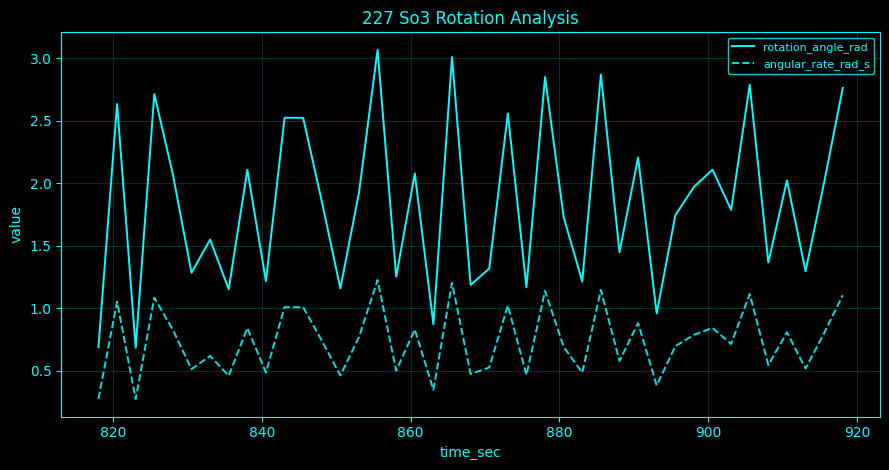

,time_sec,rotation_angle_rad,angular_rate_rad_s
0,818.071,0.690260,0.276104
1,820.571,2.635275,1.054110
2,823.071,0.686487,0.274595
3,825.571,2.715046,1.086019
4,828.071,2.070811,0.828324
5,830.571,1.285112,0.514045
6,833.071,1.550615,0.620246
7,835.571,1.153042,0.461217
8,838.071,2.109466,0.843787
9,840.571,1.218153,0.487261


In [236]:
d=np.array([so3_dist(FRAMES[i],FRAMES[i+1]) for i in range(len(FRAMES)-1)]);lgsave('227_so3_rotation_analysis',pd.DataFrame({'time_sec':FT[1:],'rotation_angle_rad':d,'angular_rate_rad_s':d/(np.diff(FT)+EPS)}))

### SE(2) rigid-motion geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — SE(2) rigid-motion geometry</h3><p>The first two PCA coordinates define planar poses using tangent orientation and position. Relative transforms live in SE(2); rotation and translation are reported separately because SE(2) has no positive-definite bi-invariant Riemannian metric.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density or iterative mean/PCA budgets; group and manifold formulas are unchanged.</p></div>

$$T=\begin{pmatrix}R(\theta)&p\0&1\end{pmatrix}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  relative_rotation_rad  translation_norm
  818.071               0.487303          5.083843
  820.571               2.649597          3.491616
  823.071               0.466186          1.602095
  825.571               0.055718          0.089839
  828.071              -1.942110          0.276425
  830.571              -2.471343          0.911388
  833.071               0.574934          1.032436
  835.571               1.020910          4.789566
  838.071               2.209691          4.094188
  840.571               0.172005          0.431113
  843.071               2.196113          0.751954
  845.571              -0.354541          1.149719


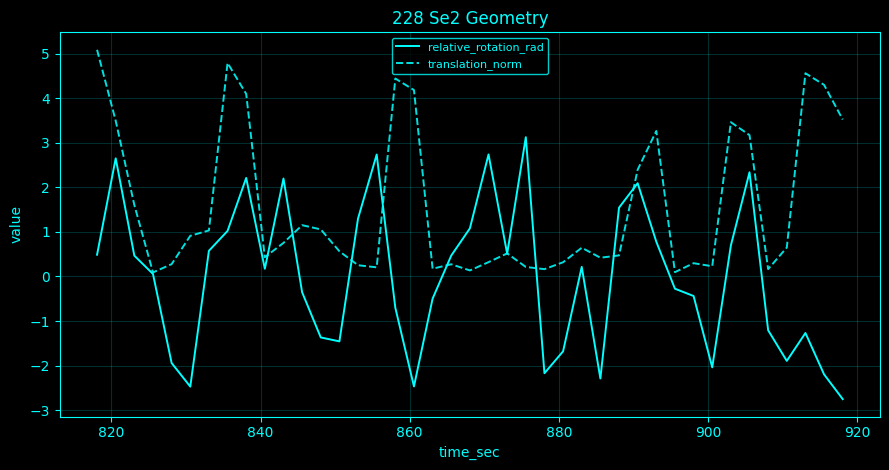

,time_sec,relative_rotation_rad,translation_norm
0,818.071,0.487303,5.083843
1,820.571,2.649597,3.491616
2,823.071,0.466186,1.602095
3,825.571,0.055718,0.089839
4,828.071,-1.942110,0.276425
5,830.571,-2.471343,0.911388
6,833.071,0.574934,1.032436
7,835.571,1.020910,4.789566
8,838.071,2.209691,4.094188
9,840.571,0.172005,0.431113


In [237]:
v2=V[pick,:2];ang=np.arctan2(v2[:,1],v2[:,0]);rows=[]
for i in range(len(pick)-1):
 da=np.angle(np.exp(1j*(ang[i+1]-ang[i])));dp=np.linalg.norm(RP[i+1,:2]-RP[i,:2]);rows.append((FT[i+1],da,dp))
lgsave('228_se2_geometry',pd.DataFrame(rows,columns=['time_sec','relative_rotation_rad','translation_norm']))

### SE(3) trajectory geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — SE(3) trajectory geometry</h3><p>Each pose combines a Frenet-like orientation frame with the three-dimensional PCA position. Relative SE(3) logarithms provide six local twist coordinates; their rotational and translational norms are kept separate.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density or iterative mean/PCA budgets; group and manifold formulas are unchanged.</p></div>

$$\xi=\log(T_i^{-1}T_{i+1})\in\mathfrak{se}(3).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  rotation_log_norm  translation_log_norm
  818.071           0.690260              5.178482
  820.571           2.635275              4.878917
  823.071           0.686487              2.403546
  825.571           2.715046              0.525595
  828.071           2.070811              0.589223
  830.571           1.285112              1.479261
  833.071           1.550615              1.070401
  835.571           1.153042              5.022913
  838.071           2.109466              4.997972
  840.571           1.218153              0.994804
  843.071           2.525222              1.644954
  845.571           2.525104              1.796736


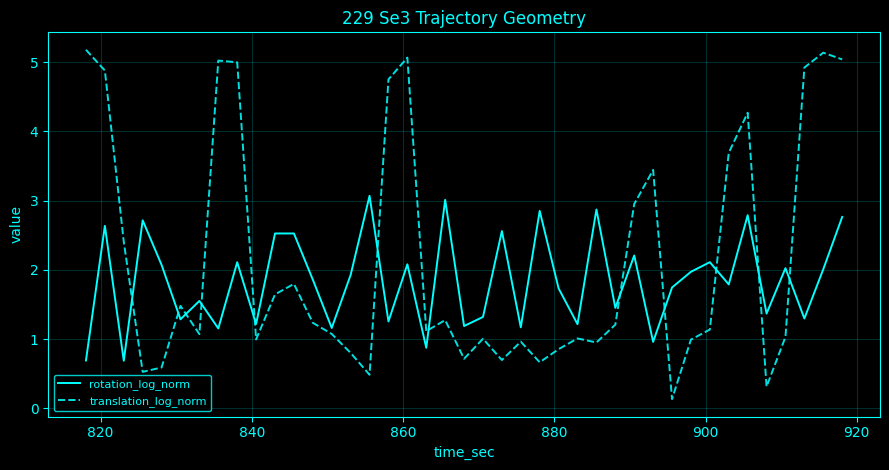

,time_sec,rotation_log_norm,translation_log_norm
0,818.071,0.690260,5.178482
1,820.571,2.635275,4.878917
2,823.071,0.686487,2.403546
3,825.571,2.715046,0.525595
4,828.071,2.070811,0.589223
5,830.571,1.285112,1.479261
6,833.071,1.550615,1.070401
7,835.571,1.153042,5.022913
8,838.071,2.109466,4.997972
9,840.571,1.218153,0.994804


In [238]:
rows=[]
for i in range(len(POSE)-1):
 xi=se3_logvec(np.linalg.inv(POSE[i])@POSE[i+1]);rows.append((FT[i+1],np.linalg.norm(xi[:3]),np.linalg.norm(xi[3:])))
lgsave('229_se3_trajectory_geometry',pd.DataFrame(rows,columns=['time_sec','rotation_log_norm','translation_log_norm']))

### Lie algebra tangent dynamics

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Lie algebra tangent dynamics</h3><p>The matrix logarithm of a relative group increment divided by elapsed time is a body-frame Lie-algebra velocity. For SO(3) it is skew-symmetric and corresponds to angular velocity.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density or iterative mean/PCA budgets; group and manifold formulas are unchanged.</p></div>

$$\Omega_i=\log(R_i^TR_{i+1})/\Delta t.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  angular_velocity_norm
  818.071               0.276104
  820.571               1.054110
  823.071               0.274595
  825.571               1.086019
  828.071               0.828324
  830.571               0.514045
  833.071               0.620246
  835.571               0.461217
  838.071               0.843787
  840.571               0.487261
  843.071               1.010089
  845.571               1.010041


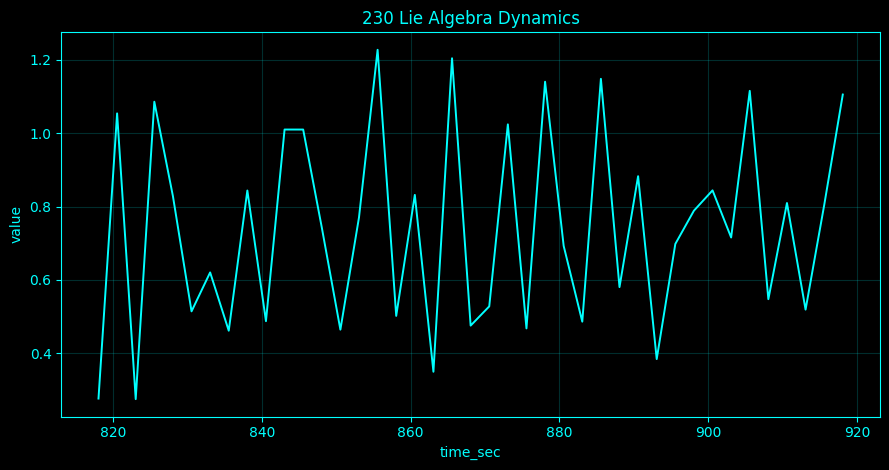

,time_sec,angular_velocity_norm
0,818.071,0.276104
1,820.571,1.054110
2,823.071,0.274595
3,825.571,1.086019
4,828.071,0.828324
5,830.571,0.514045
6,833.071,0.620246
7,835.571,0.461217
8,838.071,0.843787
9,840.571,0.487261


In [239]:
rows=[]
for i in range(len(FRAMES)-1):
 Om=np.real_if_close(logm(FRAMES[i].T@FRAMES[i+1])).astype(float)/(FT[i+1]-FT[i]+EPS);rows.append((FT[i+1],np.linalg.norm(Om,'fro')/np.sqrt(2)))
lgsave('230_lie_algebra_dynamics',pd.DataFrame(rows,columns=['time_sec','angular_velocity_norm']))

### Exponential coordinates of transformations

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Exponential coordinates of transformations</h3><p>A Lie-algebra matrix exponentiates back to its group element. The cell verifies exp(log(R_i^T R_j)) against the original relative rotation.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density or iterative mean/PCA budgets; group and manifold formulas are unchanged.</p></div>

$$\exp(\log(R))=R.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 reconstruction_error
         2.272909e-15
         5.474797e-15
         1.031284e-15
         4.093924e-15
         2.486914e-15
         7.776516e-16
         1.494249e-15
         7.773497e-16
         3.313249e-15
         5.468975e-16
         3.315020e-15
         2.769201e-15


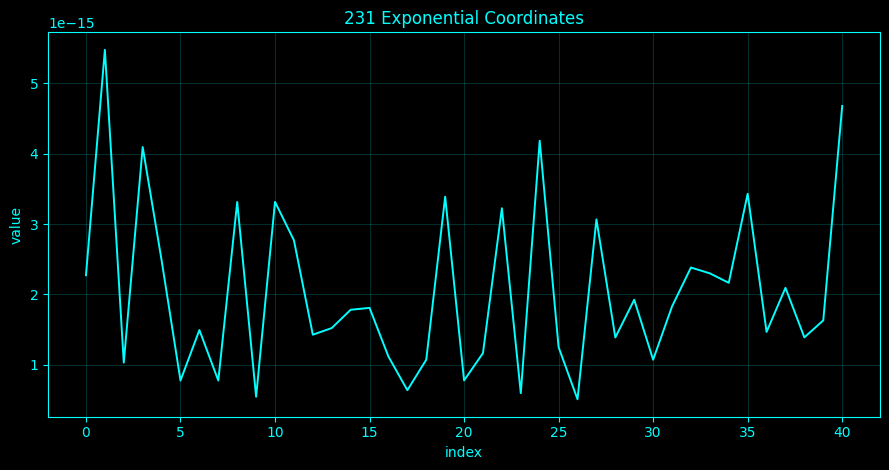

,reconstruction_error
0,2.272909e-15
1,5.474797e-15
2,1.031284e-15
3,4.093924e-15
4,2.486914e-15
5,7.776516e-16
6,1.494249e-15
7,7.773497e-16
8,3.313249e-15
9,5.468975e-16


In [240]:
errs=[]
for i in range(len(FRAMES)-1):
 Q=FRAMES[i].T@FRAMES[i+1];errs.append(np.linalg.norm(expm(logm(Q))-Q,'fro'))
lgsave('231_exponential_coordinates',pd.DataFrame({'reconstruction_error':np.real_if_close(errs).astype(float)}))

### Log-map transformation features

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Log-map transformation features</h3><p>The SO(3) logarithm is converted to a three-component rotation vector via the vee map, giving coordinate-free local transformation features in the Lie algebra.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density or iterative mean/PCA budgets; group and manifold formulas are unchanged.</p></div>

$$\omega=vee(\log(R_i^TR_{i+1})).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec        wx        wy       wz
  818.071 -0.187108  0.026243 0.663898
  820.571 -0.182211  0.020540 2.628888
  823.071 -0.160589  0.077858 0.662883
  825.571  2.620700 -0.533158 0.468137
  828.071 -0.488305 -1.572106 1.256304
  830.571  0.694052  0.634742 0.875733
  833.071  0.477477  0.186421 1.463445
  835.571  0.294951 -0.216717 1.093409
  838.071 -0.165274 -0.213717 2.092094
  840.571 -1.183542  0.202195 0.205527
  843.071  0.904676  0.521637 2.299175
  845.571  2.411391  0.247005 0.707339


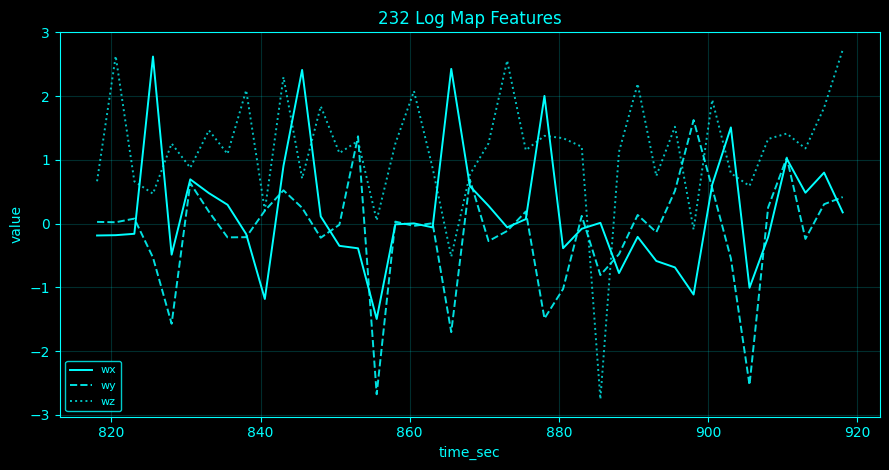

,time_sec,wx,wy,wz
0,818.071,-0.187108,0.026243,0.663898
1,820.571,-0.182211,0.020540,2.628888
2,823.071,-0.160589,0.077858,0.662883
3,825.571,2.620700,-0.533158,0.468137
4,828.071,-0.488305,-1.572106,1.256304
5,830.571,0.694052,0.634742,0.875733
6,833.071,0.477477,0.186421,1.463445
7,835.571,0.294951,-0.216717,1.093409
8,838.071,-0.165274,-0.213717,2.092094
9,840.571,-1.183542,0.202195,0.205527


In [241]:
rows=[]
for i in range(len(FRAMES)-1):
 X=np.real_if_close(logm(FRAMES[i].T@FRAMES[i+1])).astype(float);rows.append((FT[i+1],X[2,1],X[0,2],X[1,0]))
lgsave('232_log_map_features',pd.DataFrame(rows,columns=['time_sec','wx','wy','wz']))

### Baker-Campbell-Hausdorff diagnostics

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Baker-Campbell-Hausdorff diagnostics</h3><p>For small Lie-algebra elements A and B, log(exp A exp B) equals A+B+one-half[A,B] plus higher commutators. The cell measures truncation error of this second-order BCH approximation.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density or iterative mean/PCA budgets; group and manifold formulas are unchanged.</p></div>

$$\log(e^Ae^B)=A+B+\tfrac12[A,B]+O(3).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  second_order_BCH_error
  820.571                8.895742
  823.071                8.894812
  825.571                0.718699
  828.071                2.841684
  830.571                0.880941
  833.071                0.170164
  835.571                0.082505
  838.071                8.938485
  840.571                0.782114
  843.071                1.197684
  845.571               10.195598
  848.071               10.120053


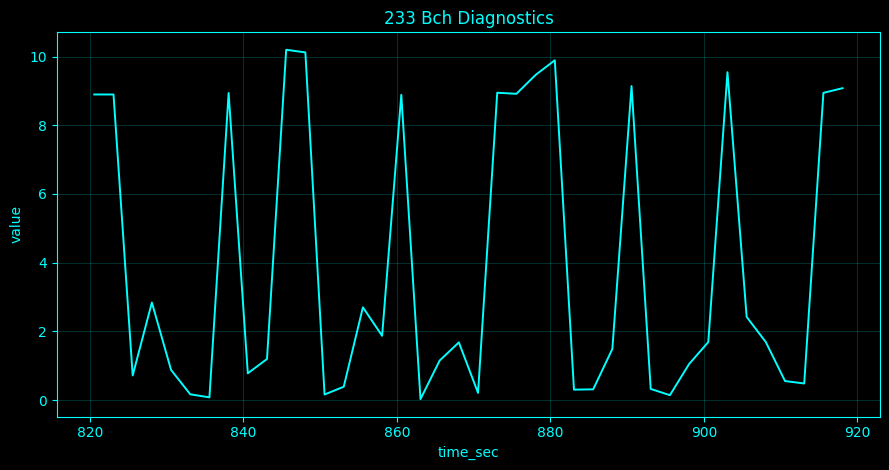

,time_sec,second_order_BCH_error
0,820.571,8.895742
1,823.071,8.894812
2,825.571,0.718699
3,828.071,2.841684
4,830.571,0.880941
5,833.071,0.170164
6,835.571,0.082505
7,838.071,8.938485
8,840.571,0.782114
9,843.071,1.197684


In [242]:
rows=[]
for i in range(len(FRAMES)-2):
 A0=logm(FRAMES[i].T@FRAMES[i+1]);B0=logm(FRAMES[i+1].T@FRAMES[i+2]);exact=logm(expm(A0)@expm(B0));approx=A0+B0+.5*(A0@B0-B0@A0);rows.append((FT[i+2],float(np.linalg.norm(exact-approx,'fro'))))
lgsave('233_bch_diagnostics',pd.DataFrame(rows,columns=['time_sec','second_order_BCH_error']))

### Lie-group distance matrices

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Lie-group distance matrices</h3><p>A subset of moving frames is compared with the exact SO(3) geodesic angle, producing a metric distance matrix on rotations.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density or iterative mean/PCA budgets; group and manifold formulas are unchanged.</p></div>

$$D_{ij}=d_{SO(3)}(R_i,R_j).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


/tmp/ipykernel_142206/2057821722.py:28: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.set_facecolor(BG); ax.grid(grid,alpha=.18,color=ACCENT); ax.tick_params(colors=ACCENT)


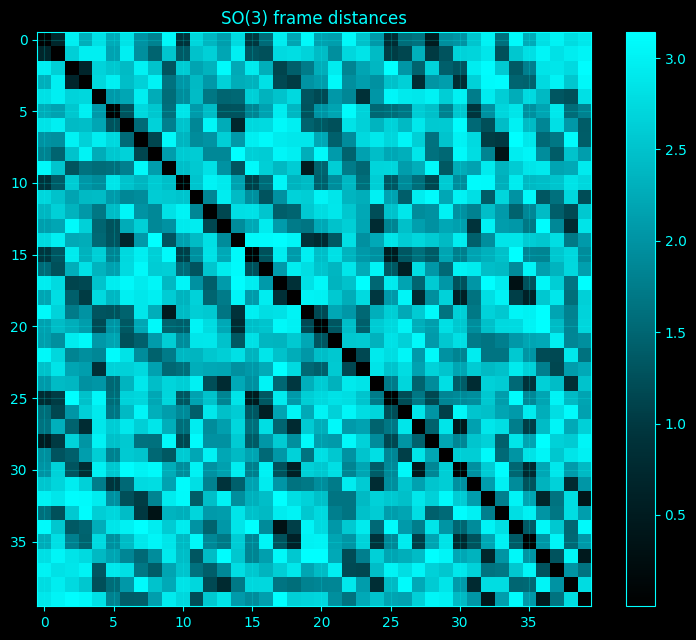

array([[2.19356025e-06, 6.90260165e-01, 2.97177839e+00, ...,
        2.99540157e+00, 2.77052954e+00, 2.89381770e+00],
       [6.90260165e-01, 3.96426903e-06, 2.63527514e+00, ...,
        2.82810000e+00, 2.94983961e+00, 3.02817435e+00],
       [2.97177839e+00, 2.63527514e+00, 5.12833805e-06, ...,
        2.87678054e+00, 2.75341427e+00, 3.11938241e+00],
       ...,
       [2.99540157e+00, 2.82810000e+00, 2.87678054e+00, ...,
        6.42957047e-06, 2.00885150e+00, 1.64883869e+00],
       [2.77052954e+00, 2.94983961e+00, 2.75341427e+00, ...,
        2.00885150e+00, 7.56641584e-06, 2.76392164e+00],
       [2.89381770e+00, 3.02817435e+00, 3.11938241e+00, ...,
        1.64883869e+00, 2.76392164e+00, 3.02181441e-06]])

In [243]:
m=min(40,len(FRAMES));jj=np.unique(np.linspace(0,len(FRAMES)-1,m).round().astype(int));D=np.array([[so3_dist(FRAMES[i],FRAMES[j]) for j in jj] for i in jj]);emit_matrix('234_lie_group_distance_matrix','SO(3) frame distances',D,[f'{FT[i]:.2f}' for i in jj])

### Lie-group barycenters

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Lie-group barycenters</h3><p>The SO(3) Karcher mean is found by iteratively averaging logarithms in the tangent space of the current estimate and exponentiating the update.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density or iterative mean/PCA budgets; group and manifold formulas are unchanged.</p></div>

$$R_{k+1}=R_k\exp\left(N^{-1}\sum_i\log(R_k^TR_i)\right).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 orthogonality_error  determinant  mean_distance
        8.036141e-16          1.0       2.098682


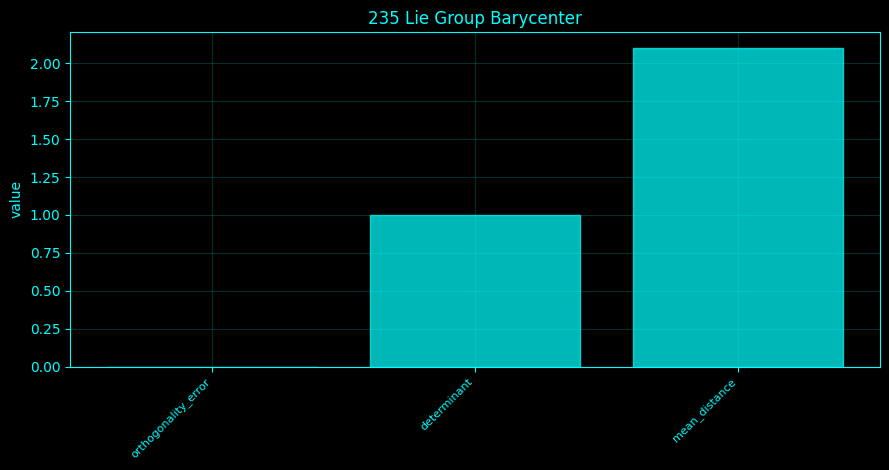

,orthogonality_error,determinant,mean_distance
0,8.036141e-16,1.0,2.098682


In [244]:
RM=so3_mean(FRAMES);lgsave('235_lie_group_barycenter',pd.DataFrame({'orthogonality_error':[np.linalg.norm(RM.T@RM-np.eye(3))],'determinant':[np.linalg.det(RM)],'mean_distance':[np.mean([so3_dist(RM,q) for q in FRAMES])]}))

### Lie-group synchronization geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Lie-group synchronization geometry</h3><p>Synchronization is summarized by dispersion of rotations about their Karcher mean. Small mean squared geodesic angle means the moving frames are tightly aligned in SO(3).</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density or iterative mean/PCA budgets; group and manifold formulas are unchanged.</p></div>

$$V=N^{-1}\sum_i d(R_i,\bar R)^2.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 mean_angle  rms_angle  max_angle
   2.098682   2.191472   2.971267


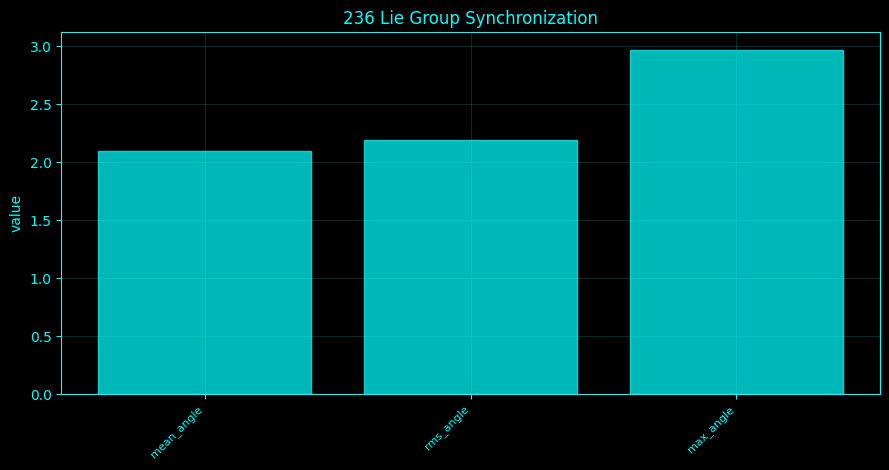

,mean_angle,rms_angle,max_angle
0,2.098682,2.191472,2.971267


In [245]:
dd=np.array([so3_dist(RM,q) for q in FRAMES]);lgsave('236_lie_group_synchronization',pd.DataFrame({'mean_angle':[dd.mean()],'rms_angle':[np.sqrt(np.mean(dd*dd))],'max_angle':[dd.max()]}))

### Rotation-vector geometry of channel pairs

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Rotation-vector geometry of channel pairs</h3><p>Proper Procrustes rotations aligning channel delay shapes to the common shape barycenter are converted to axis-angle rotation vectors. Their norms are true SO(3) rotation angles.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density or iterative mean/PCA budgets; group and manifold formulas are unchanged.</p></div>

$$\omega=\operatorname{Log}_{SO(3)}(Q)^\vee.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


channel        rx       ry        rz    angle
    Fp1  0.083743 0.122088  0.030344 0.151126
    Fpz -1.157186 0.414889  1.040818 1.610750
    Fp2 -1.235375 0.407758  1.011076 1.647632
     F7  1.393033 0.666531 -0.263047 1.566525
     F3 -0.578776 0.207401  1.754220 1.858840
     Fz -0.646920 0.266853  1.494455 1.650185
     F4 -0.599310 0.187466  1.782041 1.889441
     F8 -0.768547 0.324026  1.572604 1.780096
    FC5  1.186369 0.592144 -0.220860 1.344204
    FC1 -0.702537 0.212305  1.684465 1.837405
    FC2 -0.783262 0.217411  1.366640 1.590117
    FC6 -0.713973 0.195160  1.755836 1.905467


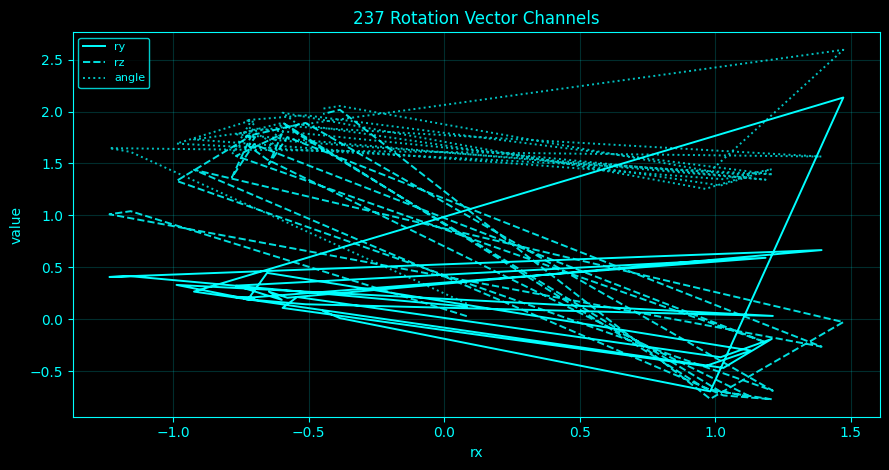

,channel,rx,ry,rz,angle
0,Fp1,0.083743,0.122088,0.030344,0.151126
1,Fpz,-1.157186,0.414889,1.040818,1.610750
2,Fp2,-1.235375,0.407758,1.011076,1.647632
3,F7,1.393033,0.666531,-0.263047,1.566525
4,F3,-0.578776,0.207401,1.754220,1.858840
5,Fz,-0.646920,0.266853,1.494455,1.650185
6,F4,-0.599310,0.187466,1.782041,1.889441
7,F8,-0.768547,0.324026,1.572604,1.780096
8,FC5,1.186369,0.592144,-0.220860,1.344204
9,FC1,-0.702537,0.212305,1.684465,1.837405


In [246]:
rows=[]
for j,X in enumerate(CH_SH):
 _,Q=lg_align(M_LG,lg_preshape(X));rv=Rot.from_matrix(Q).as_rotvec();rows.append((eeg_channel_names[j],*rv,np.linalg.norm(rv)))
lgsave('237_rotation_vector_channels',pd.DataFrame(rows,columns=['channel','rx','ry','rz','angle']))

### Unitary group U(n) geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Unitary group U(n) geometry</h3><p>Complex analytic-signal lag cross-covariance is projected to its unitary polar factor U. These factors satisfy U*U=I and live in U(n); the logarithm is skew-Hermitian up to numerical error.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density or iterative mean/PCA budgets; group and manifold formulas are unchanged.</p></div>

$$A=UH,\quad U^*U=I.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  unitarity_error
  815.571     1.421095e-15
  818.071     1.182960e-15
  820.571     1.056314e-15
  823.071     1.935852e-15
  825.571     1.758905e-15
  828.071     9.715195e-16
  830.571     2.861258e-15
  833.071     1.637463e-15
  835.571     1.604857e-15
  838.071     1.952012e-15
  840.571     1.510832e-15
  843.071     1.180879e-15


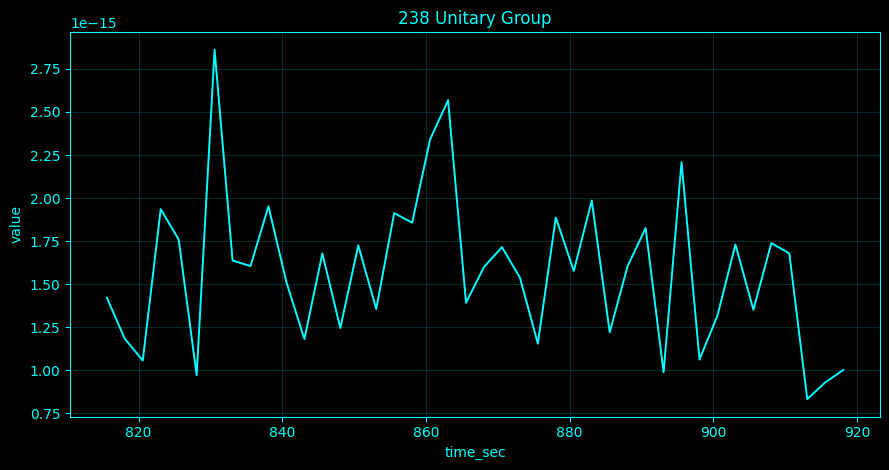

,time_sec,unitarity_error
0,815.571,1.421095e-15
1,818.071,1.182960e-15
2,820.571,1.056314e-15
3,823.071,1.935852e-15
4,825.571,1.758905e-15
5,828.071,9.715195e-16
6,830.571,2.861258e-15
7,833.071,1.637463e-15
8,835.571,1.604857e-15
9,838.071,1.952012e-15


In [247]:
AN=signal.hilbert(EEG_STD[:,:4],axis=0);UW=[]
for a,b in BOUNDS:
 X=AN[a:b-1];Y=AN[a+1:b];Axy=X.conj().T@Y;U0,_=polar(Axy);UW.append(U0)
err=[np.linalg.norm(U.conj().T@U-np.eye(4)) for U in UW];lgsave('238_unitary_group',pd.DataFrame({'time_sec':STATE_TIMES[:len(UW)],'unitarity_error':err}))

### Special unitary SU(n) geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Special unitary SU(n) geometry</h3><p>A unitary matrix is projected to SU(n) by dividing by an n-th root of its determinant. The result remains unitary and has determinant one up to numerical precision.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density or iterative mean/PCA budgets; group and manifold formulas are unchanged.</p></div>

$$\tilde U=U/(\det U)^{1/n},\quad\det\tilde U=1.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  det_abs_error  unitarity_error
  815.571   1.115760e-15     1.544728e-15
  818.071   1.110223e-16     1.182553e-15
  820.571   1.110223e-16     1.086429e-15
  823.071   1.781770e-15     2.009507e-15
  825.571   9.226381e-16     1.911336e-15
  828.071   8.349770e-16     9.203562e-16
  830.571   2.442648e-15     3.008704e-15
  833.071   0.000000e+00     1.510560e-15
  835.571   4.742875e-16     1.523721e-15
  838.071   1.447554e-15     1.943896e-15
  840.571   2.482534e-16     1.576607e-15
  843.071   2.775558e-17     1.236893e-15


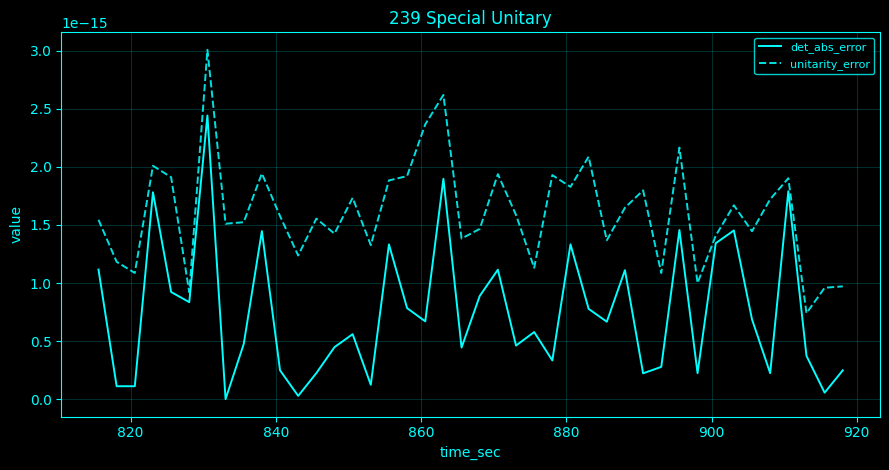

,time_sec,det_abs_error,unitarity_error
0,815.571,1.115760e-15,1.544728e-15
1,818.071,1.110223e-16,1.182553e-15
2,820.571,1.110223e-16,1.086429e-15
3,823.071,1.781770e-15,2.009507e-15
4,825.571,9.226381e-16,1.911336e-15
5,828.071,8.349770e-16,9.203562e-16
6,830.571,2.442648e-15,3.008704e-15
7,833.071,0.000000e+00,1.510560e-15
8,835.571,4.742875e-16,1.523721e-15
9,838.071,1.447554e-15,1.943896e-15


In [248]:
SU=[]
for U in UW:
 phase=np.angle(np.linalg.det(U));S0=U*np.exp(-1j*phase/U.shape[0]);SU.append(S0)
lgsave('239_special_unitary',pd.DataFrame({'time_sec':STATE_TIMES[:len(SU)],'det_abs_error':[abs(np.linalg.det(U)-1) for U in SU],'unitarity_error':[np.linalg.norm(U.conj().T@U-np.eye(U.shape[0])) for U in SU]}))

### Orthogonal group O(n) geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Orthogonal group O(n) geometry</h3><p>The real polar factor of lag cross-covariance gives an orthogonal transformation. Determinant sign distinguishes rotations from reflections in O(n).</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density or iterative mean/PCA budgets; group and manifold formulas are unchanged.</p></div>

$$A=QH,\quad Q^TQ=I,\quad\det Q=\pm1.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  orthogonality_error  determinant
  815.571         1.307378e-15          1.0
  818.071         1.729131e-15          1.0
  820.571         1.547091e-15          1.0
  823.071         9.617812e-16          1.0
  825.571         1.016100e-15          1.0
  828.071         1.410481e-15          1.0
  830.571         1.912415e-15          1.0
  833.071         9.687404e-16          1.0
  835.571         1.888958e-15          1.0
  838.071         1.933133e-15          1.0
  840.571         1.795016e-15          1.0
  843.071         9.319604e-16          1.0


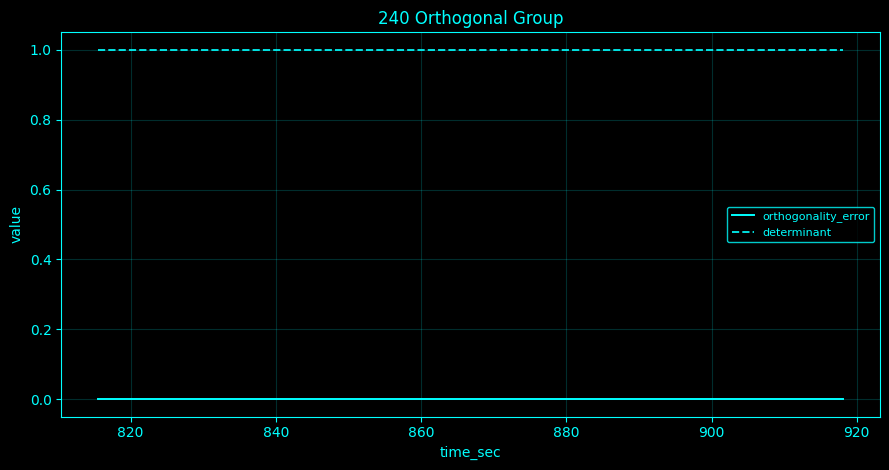

,time_sec,orthogonality_error,determinant
0,815.571,1.307378e-15,1.0
1,818.071,1.729131e-15,1.0
2,820.571,1.547091e-15,1.0
3,823.071,9.617812e-16,1.0
4,825.571,1.016100e-15,1.0
5,828.071,1.410481e-15,1.0
6,830.571,1.912415e-15,1.0
7,833.071,9.687404e-16,1.0
8,835.571,1.888958e-15,1.0
9,838.071,1.933133e-15,1.0


In [249]:
OW=[]
for a,b in BOUNDS:
 X=EEG_STD[a:b-1,:4];Y=EEG_STD[a+1:b,:4];Q,_=polar(X.T@Y);OW.append(Q)
lgsave('240_orthogonal_group',pd.DataFrame({'time_sec':STATE_TIMES[:len(OW)],'orthogonality_error':[np.linalg.norm(Q.T@Q-np.eye(4)) for Q in OW],'determinant':[np.linalg.det(Q) for Q in OW]}))

### Stiefel manifold geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Stiefel manifold geometry</h3><p>Each top-k covariance eigenframe has orthonormal columns and is therefore a point on the Stiefel manifold St(k,n). The cell verifies the defining orthonormality constraint.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density or iterative mean/PCA budgets; group and manifold formulas are unchanged.</p></div>

$$St(k,n)=\{X\in\mathbb R^{n\times k}:X^TX=I_k\}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  orthonormality_error
  815.571          1.824459e-15
  818.071          1.527882e-15
  820.571          1.751898e-15
  823.071          2.061948e-15
  825.571          1.715112e-15
  828.071          9.663009e-16
  830.571          1.455505e-15
  833.071          1.673795e-15
  835.571          1.051377e-15
  838.071          1.200083e-15
  840.571          1.625316e-15
  843.071          1.429923e-15


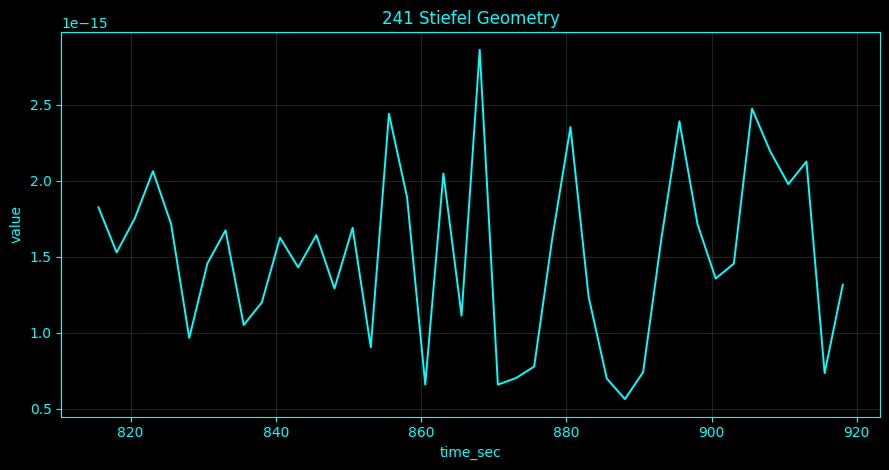

,time_sec,orthonormality_error
0,815.571,1.824459e-15
1,818.071,1.527882e-15
2,820.571,1.751898e-15
3,823.071,2.061948e-15
4,825.571,1.715112e-15
5,828.071,9.663009e-16
6,830.571,1.455505e-15
7,833.071,1.673795e-15
8,835.571,1.051377e-15
9,838.071,1.200083e-15


In [250]:
lgsave('241_stiefel_geometry',pd.DataFrame({'time_sec':STATE_TIMES,'orthonormality_error':[np.linalg.norm(U.T@U-np.eye(kG)) for U in US]}))

### Grassmann manifold geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Grassmann manifold geometry</h3><p>The Grassmann manifold identifies Stiefel frames differing only by a right orthogonal basis change. Principal angles therefore characterize subspace geometry independently of eigenvector sign or internal rotation.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density or iterative mean/PCA budgets; group and manifold formulas are unchanged.</p></div>

$$Gr(k,n)=St(k,n)/O(k).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  grassmann_step_distance
  818.071                 0.853448
  820.571                 0.546370
  823.071                 0.967201
  825.571                 0.439103
  828.071                 0.978854
  830.571                 0.920774
  833.071                 0.458381
  835.571                 0.929185
  838.071                 0.668021
  840.571                 0.837632
  843.071                 0.533661
  845.571                 0.564887


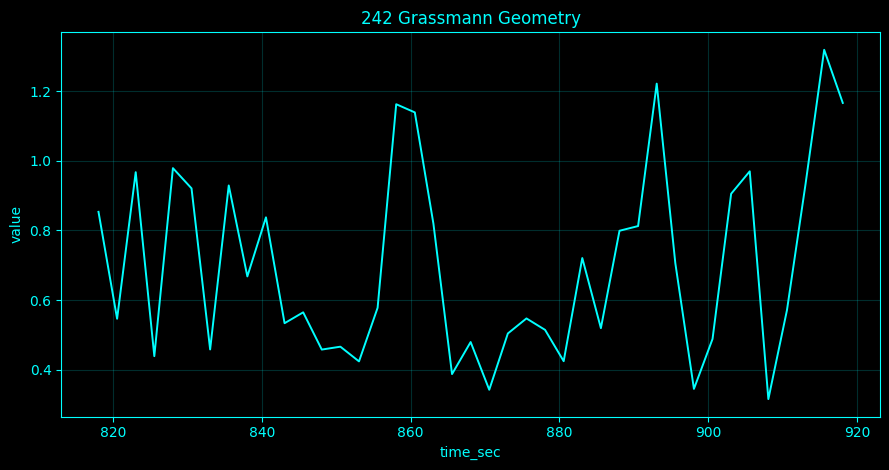

,time_sec,grassmann_step_distance
0,818.071,0.853448
1,820.571,0.546370
2,823.071,0.967201
3,825.571,0.439103
4,828.071,0.978854
5,830.571,0.920774
6,833.071,0.458381
7,835.571,0.929185
8,838.071,0.668021
9,840.571,0.837632


In [251]:
d=[grass_dist(US[i],US[i+1]) for i in range(len(US)-1)];lgsave('242_grassmann_geometry',pd.DataFrame({'time_sec':STATE_TIMES[1:],'grassmann_step_distance':d}))

### Grassmannian subspace distances

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Grassmannian subspace distances</h3><p>If cos(theta_i) are singular values of X^T Y, the canonical Grassmann geodesic distance is the Euclidean norm of the principal-angle vector.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density or iterative mean/PCA budgets; group and manifold formulas are unchanged.</p></div>

$$\cos\theta_i=\sigma_i(X^TY),\quad d=\sqrt{\sum_i\theta_i^2}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


/tmp/ipykernel_142206/2057821722.py:28: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.set_facecolor(BG); ax.grid(grid,alpha=.18,color=ACCENT); ax.tick_params(colors=ACCENT)


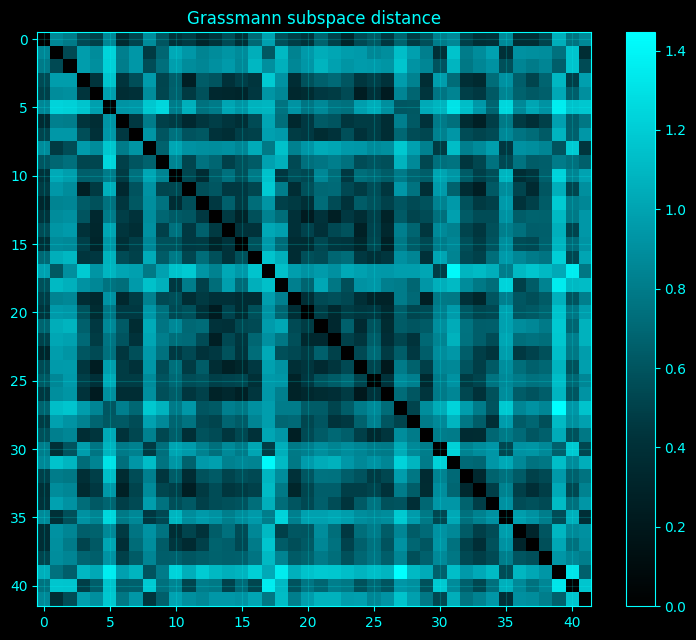

array([[0.00000000e+00, 8.53447663e-01, 7.94183806e-01, ...,
        1.05609782e+00, 7.62084332e-01, 8.67302905e-01],
       [8.53447663e-01, 7.74287048e-08, 5.46370321e-01, ...,
        7.48542929e-01, 1.16583324e+00, 3.79951447e-01],
       [7.94183806e-01, 5.46370321e-01, 6.49526558e-08, ...,
        6.50441641e-01, 1.16010817e+00, 5.57015942e-01],
       ...,
       [1.05609782e+00, 7.48542929e-01, 6.50441641e-01, ...,
        7.88495335e-08, 1.31858763e+00, 6.63172996e-01],
       [7.62084332e-01, 1.16583324e+00, 1.16010817e+00, ...,
        1.31858763e+00, 5.37269007e-08, 1.16606106e+00],
       [8.67302905e-01, 3.79951447e-01, 5.57015942e-01, ...,
        6.63172996e-01, 1.16606106e+00, 4.47034836e-08]])

In [252]:
m=min(45,len(US));jj=np.unique(np.linspace(0,len(US)-1,m).round().astype(int));D=np.array([[grass_dist(US[i],US[j]) for j in jj] for i in jj]);emit_matrix('243_grassmann_distance_matrix','Grassmann subspace distance',D,[f'{STATE_TIMES[i]:.2f}' for i in jj])

### Grassmannian geodesics

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Grassmannian geodesics</h3><p>A Grassmann geodesic is generated from the tangent logarithm obtained through the off-subspace map (I-XX^T)Y(X^TY)^-1. Principal angles evolve linearly along the geodesic.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density or iterative mean/PCA budgets; group and manifold formulas are unchanged.</p></div>

$$\Gamma(t)=XV\cos(t\Theta)V^T+U\sin(t\Theta)V^T.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


   t  distance_from_start  expected  orthonormality_error
0.00             0.000000  0.000000          5.980908e-16
0.05             0.043365  0.043365          5.126477e-16
0.10             0.086730  0.086730          1.617313e-16
0.15             0.130095  0.130095          3.461028e-16
0.20             0.173461  0.173461          3.021485e-16
0.25             0.216826  0.216826          7.412030e-16
0.30             0.260191  0.260191          5.859596e-16
0.35             0.303556  0.303556          4.651294e-16
0.40             0.346921  0.346921          3.605663e-16
0.45             0.390286  0.390286          6.456287e-16
0.50             0.433651  0.433651          2.617168e-16
0.55             0.477017  0.477017          2.636233e-16


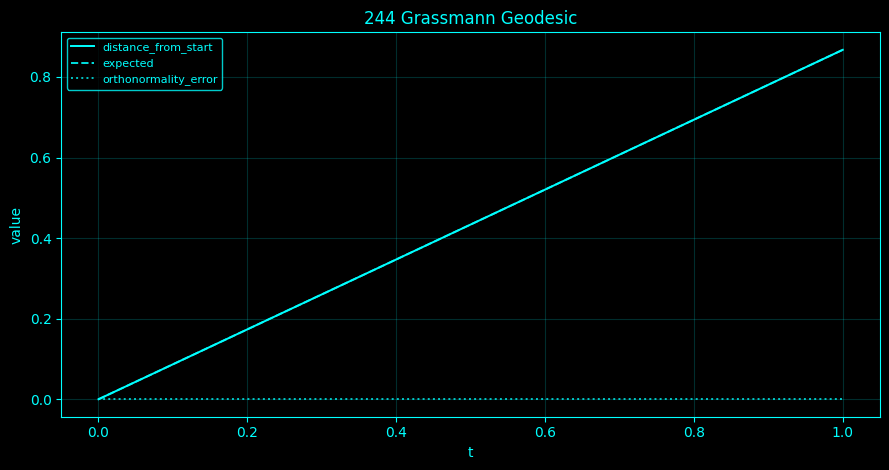

,t,distance_from_start,expected,orthonormality_error
0,0.00,0.000000,0.000000,5.980908e-16
1,0.05,0.043365,0.043365,5.126477e-16
2,0.10,0.086730,0.086730,1.617313e-16
3,0.15,0.130095,0.130095,3.461028e-16
4,0.20,0.173461,0.173461,3.021485e-16
5,0.25,0.216826,0.216826,7.412030e-16
6,0.30,0.260191,0.260191,5.859596e-16
7,0.35,0.303556,0.303556,4.651294e-16
8,0.40,0.346921,0.346921,3.605663e-16
9,0.45,0.390286,0.390286,6.456287e-16


In [253]:
X,Y=US[0],US[-1];D=grass_dist(X,Y);rows=[]
for t in np.linspace(0,1,21):Gg=grass_geodesic(X,Y,t);rows.append((t,grass_dist(X,Gg),t*D,np.linalg.norm(Gg.T@Gg-np.eye(kG))))
lgsave('244_grassmann_geodesic',pd.DataFrame(rows,columns=['t','distance_from_start','expected','orthonormality_error']))

### Grassmannian PCA

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Grassmannian PCA</h3><p>Subspaces are represented by projection matrices P=XX^T, which remove basis ambiguity. PCA of vectorized centered projection matrices is an extrinsic Grassmann variation analysis and is labelled accordingly.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density or iterative mean/PCA budgets; group and manifold formulas are unchanged.</p></div>

$$P_X=XX^T,\quad\|P_X-P_Y\|_F^2=2\sum_i\sin^2\theta_i.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 component  extrinsic_projection_variance_fraction
         1                                0.290887
         2                                0.173631
         3                                0.140829
         4                                0.073267
         5                                0.050202
         6                                0.041573
         7                                0.032507
         8                                0.025181
         9                                0.020491
        10                                0.016463


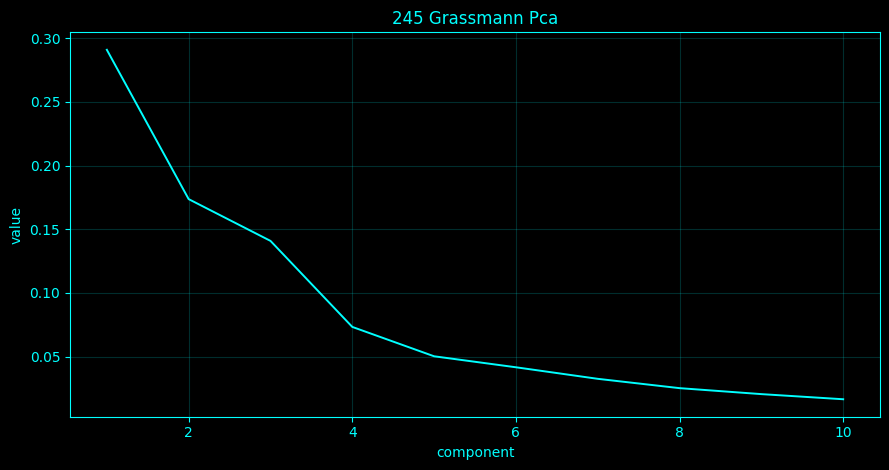

,component,extrinsic_projection_variance_fraction
0,1,0.290887
1,2,0.173631
2,3,0.140829
3,4,0.073267
4,5,0.050202
5,6,0.041573
6,7,0.032507
7,8,0.025181
8,9,0.020491
9,10,0.016463


In [254]:
PF=np.stack([(U@U.T).ravel() for U in US]);_,s,_=np.linalg.svd(PF-PF.mean(0),full_matrices=False);ev=s*s/max(len(PF)-1,1);lgsave('245_grassmann_pca',pd.DataFrame({'component':np.arange(1,min(10,len(ev))+1),'extrinsic_projection_variance_fraction':ev[:10]/(ev.sum()+EPS)}))

### Subspace-angle geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Subspace-angle geometry</h3><p>The full vector of principal angles retains directional information lost in a single Grassmann distance. Consecutive covariance subspaces are summarized angle by angle.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density or iterative mean/PCA budgets; group and manifold formulas are unchanged.</p></div>

$$0\le\theta_1\le\cdots\le\theta_k\le\pi/2.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  theta_1  theta_2  theta_3
  818.071 0.014275 0.168605 0.836505
  820.571 0.014632 0.335712 0.430818
  823.071 0.020981 0.165345 0.952733
  825.571 0.012406 0.185624 0.397745
  828.071 0.015543 0.236817 0.949648
  830.571 0.011530 0.228266 0.891956
  833.071 0.013396 0.184015 0.419609
  835.571 0.015355 0.311309 0.875348
  838.071 0.013797 0.305887 0.593712
  840.571 0.016438 0.259164 0.796361
  843.071 0.020126 0.177020 0.503044
  845.571 0.030217 0.268247 0.496214


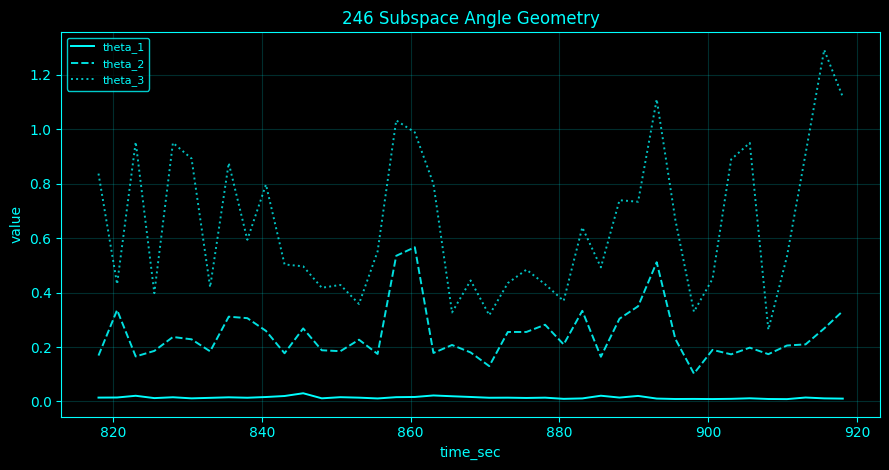

,time_sec,theta_1,theta_2,theta_3
0,818.071,0.014275,0.168605,0.836505
1,820.571,0.014632,0.335712,0.430818
2,823.071,0.020981,0.165345,0.952733
3,825.571,0.012406,0.185624,0.397745
4,828.071,0.015543,0.236817,0.949648
5,830.571,0.011530,0.228266,0.891956
6,833.071,0.013396,0.184015,0.419609
7,835.571,0.015355,0.311309,0.875348
8,838.071,0.013797,0.305887,0.593712
9,840.571,0.016438,0.259164,0.796361


In [255]:
rows=[]
for i in range(len(US)-1):rows.append([STATE_TIMES[i+1],*principal_angles(US[i],US[i+1])])
lgsave('246_subspace_angle_geometry',pd.DataFrame(rows,columns=['time_sec']+[f'theta_{j+1}' for j in range(kG)]))

### Principal-angle trajectories

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Principal-angle trajectories</h3><p>Each principal angle is tracked through time for consecutive window eigenspaces, distinguishing rotation of the dominant covariance subspace from changes confined to weaker directions.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density or iterative mean/PCA budgets; group and manifold formulas are unchanged.</p></div>

$$\theta_j(t)=\arccos\sigma_j(U_t^TU_{t+1}).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 time_sec  theta_1  theta_2  theta_3
  818.071 0.014275 0.168605 0.836505
  820.571 0.014632 0.335712 0.430818
  823.071 0.020981 0.165345 0.952733
  825.571 0.012406 0.185624 0.397745
  828.071 0.015543 0.236817 0.949648
  830.571 0.011530 0.228266 0.891956
  833.071 0.013396 0.184015 0.419609
  835.571 0.015355 0.311309 0.875348
  838.071 0.013797 0.305887 0.593712
  840.571 0.016438 0.259164 0.796361
  843.071 0.020126 0.177020 0.503044
  845.571 0.030217 0.268247 0.496214


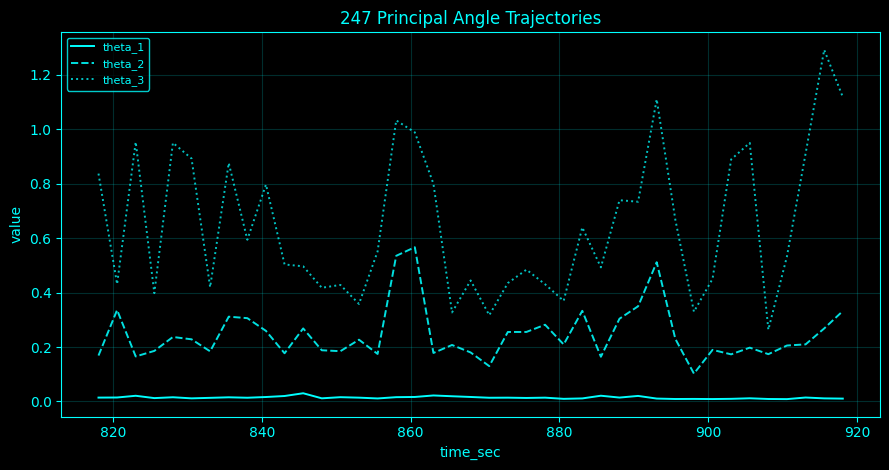

,time_sec,theta_1,theta_2,theta_3
0,818.071,0.014275,0.168605,0.836505
1,820.571,0.014632,0.335712,0.430818
2,823.071,0.020981,0.165345,0.952733
3,825.571,0.012406,0.185624,0.397745
4,828.071,0.015543,0.236817,0.949648
5,830.571,0.011530,0.228266,0.891956
6,833.071,0.013396,0.184015,0.419609
7,835.571,0.015355,0.311309,0.875348
8,838.071,0.013797,0.305887,0.593712
9,840.571,0.016438,0.259164,0.796361


In [256]:
df=pd.DataFrame(rows,columns=['time_sec']+[f'theta_{j+1}' for j in range(kG)]);lgsave('247_principal_angle_trajectories',df)

### Channel-subspace geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Channel-subspace geometry</h3><p>Left, right and midline channel groups are embedded as subspaces of five-dimensional band-power feature space. QR bases allow Grassmann principal-angle comparison between regional spectral spans with a common ambient dimension.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density or iterative mean/PCA budgets; group and manifold formulas are unchanged.</p></div>

$$d_{Gr}(\mathcal S_R,\mathcal S_S)=\|\Theta\|_2.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


/tmp/ipykernel_142206/2057821722.py:28: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.set_facecolor(BG); ax.grid(grid,alpha=.18,color=ACCENT); ax.tick_params(colors=ACCENT)


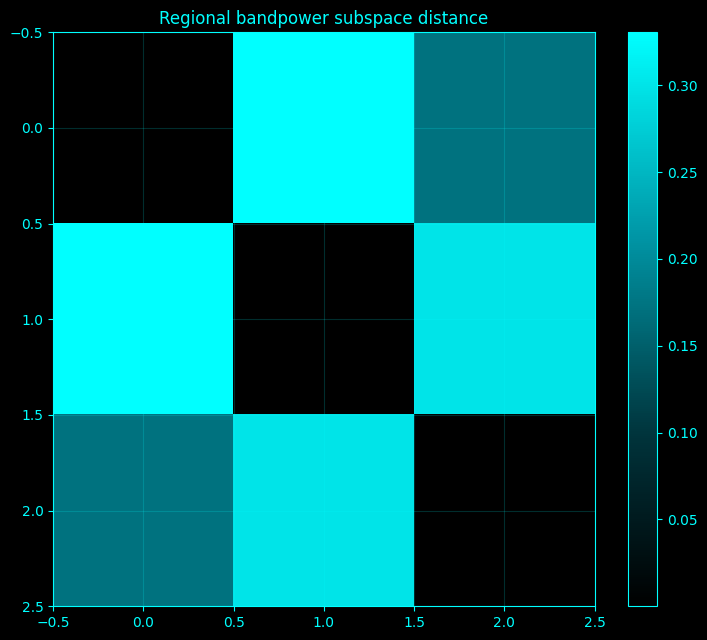

array([[2.58095683e-08, 3.30437611e-01, 1.72653864e-01],
       [3.30437611e-01, 2.58095683e-08, 2.99571179e-01],
       [1.72653864e-01, 2.99571179e-01, 2.10734243e-08]])

In [257]:
regs={'left':LEFT,'right':RIGHT,'midline':MID};RB={}
for name,ids in regs.items():
 A0=BP_PROB[:,ids];Q,_=np.linalg.qr(A0);RB[name]=Q[:,:min(3,Q.shape[1])]
labs=list(RB);D=np.array([[grass_dist(RB[a],RB[b]) for b in labs] for a in labs]);emit_matrix('248_channel_subspace_geometry','Regional bandpower subspace distance',D,labs)

### Frequency-band subspace geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Frequency-band subspace geometry</h3><p>Each band-filtered multichannel signal yields a covariance matrix; its leading three channel-space eigenvectors define a band-specific subspace. Grassmann distance compares these spectral covariance subspaces.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density or iterative mean/PCA budgets; group and manifold formulas are unchanged.</p></div>

$$\mathcal S_B=span\{u_1(C_B),u_2(C_B),u_3(C_B)\}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


/tmp/ipykernel_142206/2057821722.py:28: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.set_facecolor(BG); ax.grid(grid,alpha=.18,color=ACCENT); ax.tick_params(colors=ACCENT)


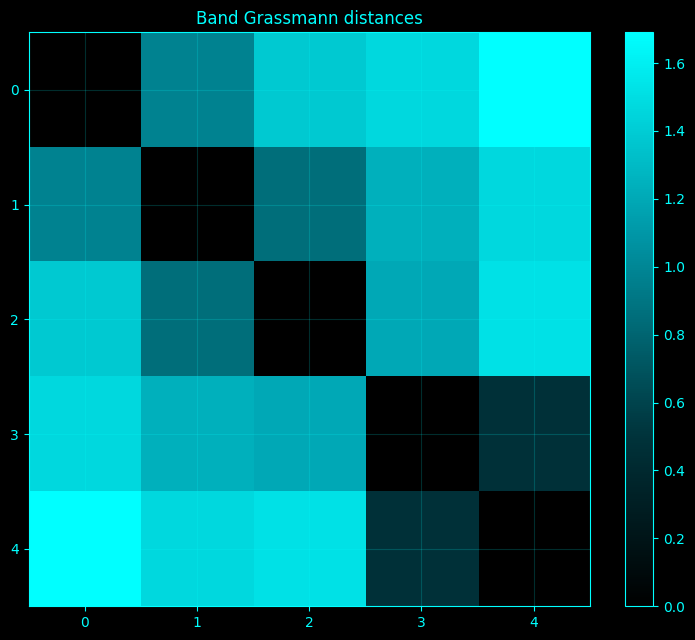

array([[5.16191366e-08, 9.74997229e-01, 1.38076486e+00, 1.47209088e+00,
        1.69061358e+00],
       [9.74997229e-01, 0.00000000e+00, 8.54605159e-01, 1.24432372e+00,
        1.47210420e+00],
       [1.38076486e+00, 8.54605159e-01, 5.57550399e-08, 1.20106606e+00,
        1.52005811e+00],
       [1.47209088e+00, 1.24432372e+00, 1.20106606e+00, 2.58095683e-08,
        4.77144821e-01],
       [1.69061358e+00, 1.47210420e+00, 1.52005811e+00, 4.77144821e-01,
        1.49011612e-08]])

In [258]:
BU=[];labs=[b[0] for b in BANDS]
for bn,lo,hi in BANDS:
 sos=signal.butter(4,[lo,hi],btype='bandpass',fs=sampling_rate,output='sos');xf=signal.sosfiltfilt(sos,EEG_STD,axis=0);C=np.cov(xf,rowvar=False);w,Q=np.linalg.eigh(C);BU.append(Q[:,np.argsort(w)[-kG:]])
D=np.array([[grass_dist(a,b) for b in BU] for a in BU]);emit_matrix('249_frequency_band_subspaces','Band Grassmann distances',D,labs)

### Time-window subspace geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Time-window subspace geometry</h3><p>The dominant covariance subspace in each window is a trajectory on Gr(k,n). Consecutive Grassmann distances quantify subspace drift over time.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density or iterative mean/PCA budgets; group and manifold formulas are unchanged.</p></div>

$$d_t=\|\Theta(U_t,U_{t+1})\|_2.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 time_sec  grassmann_distance
  818.071            0.853448
  820.571            0.546370
  823.071            0.967201
  825.571            0.439103
  828.071            0.978854
  830.571            0.920774
  833.071            0.458381
  835.571            0.929185
  838.071            0.668021
  840.571            0.837632
  843.071            0.533661
  845.571            0.564887


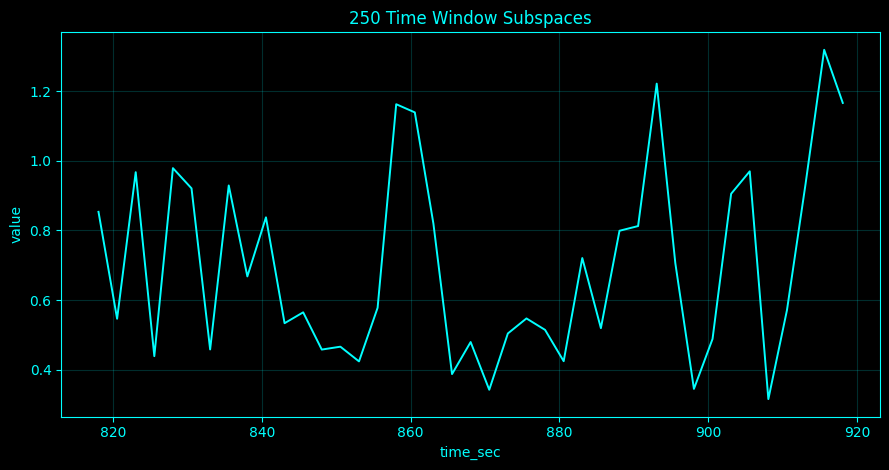

,time_sec,grassmann_distance
0,818.071,0.853448
1,820.571,0.546370
2,823.071,0.967201
3,825.571,0.439103
4,828.071,0.978854
5,830.571,0.920774
6,833.071,0.458381
7,835.571,0.929185
8,838.071,0.668021
9,840.571,0.837632


In [259]:
lgsave('250_time_window_subspaces',pd.DataFrame({'time_sec':STATE_TIMES[1:],'grassmann_distance':[grass_dist(US[i],US[i+1]) for i in range(len(US)-1)]}))

# Geometry catalogue continuation — entries 251–285


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> This continuation constructs genuine canonical symplectic coordinates from a low-dimensional EEG trajectory, a standard Darboux contact chart, and complex analytic-signal states. Model-dependent quantities are labelled as diagnostics or proxies rather than intrinsic properties of EEG. <br><br>$$\omega(u,v)=u^TJv,\qquad J=\begin{pmatrix}0&I\\-I&0\end{pmatrix}.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


Symplectic/contact/complex foundation: ultra phase points 700 HPD windows 42


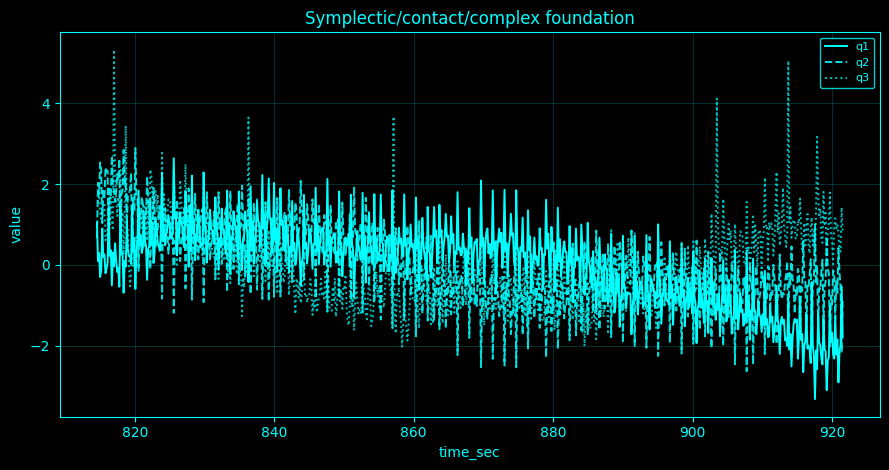

True

In [260]:
from scipy.linalg import expm,logm
SC_CFG={'full':dict(points=2600,windows=100,iter=36,bandsamp=2200),'balanced':dict(points=1800,windows=75,iter=26,bandsamp=1600),'fast':dict(points=1200,windows=55,iter=18,bandsamp=1000),'ultra':dict(points=700,windows=35,iter=10,bandsamp=650)}[FAST_OPTION]
SC_OUT=os.path.join(base_dir,'results','geometry_catalogue_symplectic_contact_complex');os.makedirs(SC_OUT,exist_ok=True)
def scdir(s):d=os.path.join(SC_OUT,s);os.makedirs(d,exist_ok=True);return d
def scsave(s,df):df.to_csv(os.path.join(scdir(s),f'{s}_{FAST_OPTION}.csv'),index=False);print(df.head(12).to_string(index=False));catalogue_autoplot_df(s,df);return df
# continuous 3-coordinate PCA trajectory, then canonical momenta as time derivatives
m=min(len(EEG_STD),SC_CFG['points']);si=np.unique(np.linspace(0,len(EEG_STD)-1,m).round().astype(int));XX=EEG_STD[si];tt=(si/sampling_rate)+start_time
_,_,Vt=np.linalg.svd(XX-XX.mean(0),full_matrices=False);Q=(XX-XX.mean(0))@Vt[:3].T;Q/=np.std(Q,axis=0,keepdims=True)+EPS
P=np.gradient(Q,tt,axis=0);P/=np.std(P,axis=0,keepdims=True)+EPS
Z6=np.c_[Q,P];dZ=np.gradient(Z6,tt,axis=0);J6=np.block([[np.zeros((3,3)),np.eye(3)],[-np.eye(3),np.zeros((3,3))]])
def omega(u,v):return float(np.asarray(u)@J6@np.asarray(v))
def fit_linear(X,Y,ridge=1e-5):return np.linalg.solve(X.T@X+ridge*np.eye(X.shape[1]),X.T@Y).T
def symplectic_eigs(S):
 S=.5*(S+S.T);w=np.sort(np.abs(np.real_if_close(np.linalg.eigvals(1j*J6@S)).real));return .5*(w[::2]+w[1::2])
def phase_cov(A):return reg(np.cov(A,rowvar=False),.02)
# contact Darboux coordinates (q1,q2,p1,p2,z)
C5=np.c_[Q[:,:2],P[:,:2],Q[:,2]];dC5=np.gradient(C5,tt,axis=0)
def contact_alpha_vel(x,v):return float(v[4]-x[2]*v[0]-x[3]*v[1])
# complex analytic-signal states and window HPD covariances
AN=signal.hilbert(EEG_STD,axis=0);cp_n=min(len(AN),SC_CFG['points']);ci=np.unique(np.linspace(0,len(AN)-1,cp_n).round().astype(int));CP=AN[ci,:8];CP/=np.linalg.norm(CP,axis=1,keepdims=True)+EPS;CPT=start_time+ci/sampling_rate
def fsdist(z,w):return float(np.arccos(np.clip(abs(np.vdot(z,w)),-1,1)))
def heigh(A,floor=1e-10):
 A=(A+A.conj().T)/2;w,V=np.linalg.eigh(A);return np.maximum(w,floor),V
def hpow(A,p):w,V=heigh(A);return (V*(w**p))@V.conj().T
def hlog(A):w,V=heigh(A);return (V*np.log(w))@V.conj().T
def hexp(A):A=(A+A.conj().T)/2;w,V=np.linalg.eigh(A);return (V*np.exp(np.clip(w,-50,50)))@V.conj().T
def hreg(A):
 A=(A+A.conj().T)/2;n=len(A);sc=max(float(np.trace(A).real/n),1e-9);return .98*A+.02*sc*np.eye(n)
def hairm(A,B):Ai=hpow(A,-.5);return float(np.linalg.norm(hlog(Ai@B@Ai),'fro'))
def hgeo(A,B,t):Ah=hpow(A,.5);Ai=hpow(A,-.5);return Ah@hpow(Ai@B@Ai,t)@Ah
def hmean(S):
 G=hreg(sum(S)/len(S))
 for _ in range(SC_CFG['iter']):
  Gi=hpow(G,-.5);D=sum(hlog(Gi@A@Gi) for A in S)/len(S);G=hpow(G,.5)@hexp(D)@hpow(G,.5)
  if np.linalg.norm(D,'fro')<1e-8:break
 return hreg(G)
HC=[];HT=[]
for a,b in BOUNDS:
 Z=AN[a:b,:8];C=Z.conj().T@Z/max(len(Z),1);HC.append(hreg(C));HT.append(start_time+(a+b)/(2*sampling_rate))
HC=np.asarray(HC);HT=np.asarray(HT)
print('Symplectic/contact/complex foundation:',FAST_OPTION,'phase points',len(Z6),'HPD windows',len(HC))

# Visible foundation diagnostic
catalogue_autoplot_df('symplectic_contact_foundation',pd.DataFrame({'time_sec':tt,'q1':Q[:,0],'q2':Q[:,1],'q3':Q[:,2]}),title='Symplectic/contact/complex foundation')


### Symplectic geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> The chosen six-dimensional phase chart uses three PCA coordinates q and their standardized time derivatives p. The canonical symplectic form is nondegenerate and antisymmetric. This is a mathematical phase-space representation, not a claim of literal physical Hamiltonian dynamics.<br><br>$$\omega=\sum_{j=1}^{3}dq_j\wedge dp_j,\qquad \omega(u,v)=u^TJv.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  omega_successive_tangents
  814.724                 -45.158080
  814.877                   8.190311
  815.030                 -22.848880
  815.183                 -78.162961
  815.336                 -76.011880
  815.489                 -40.662329
  815.642                 -21.513078
  815.795                 -23.855160
  815.948                 -54.180534
  816.101                -128.904596
  816.254                -154.039886
  816.407                -105.931804


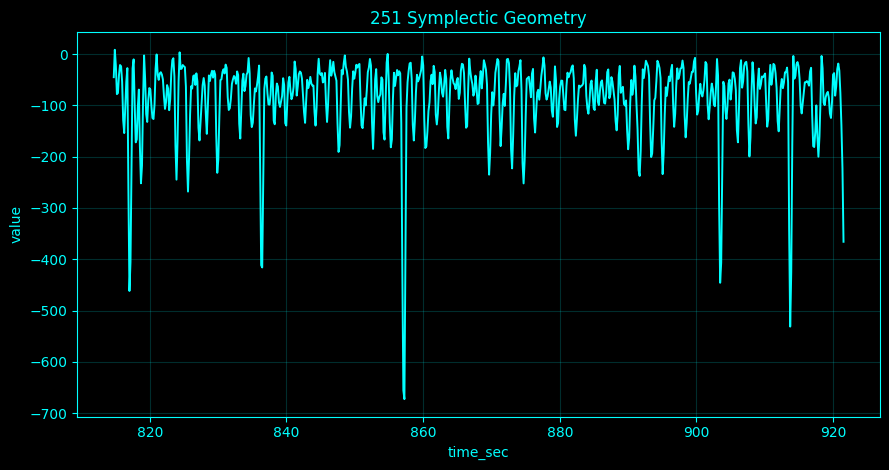

,time_sec,omega_successive_tangents
0,814.724,-45.158080
1,814.877,8.190311
2,815.030,-22.848880
3,815.183,-78.162961
4,815.336,-76.011880
...,...,...
694,920.902,-32.592830
695,921.055,-75.996450
696,921.208,-139.273066
697,921.361,-222.775682


In [261]:
vals=np.array([omega(dZ[i],dZ[i+1]) for i in range(len(dZ)-1)]);scsave('251_symplectic_geometry',pd.DataFrame({'time_sec':tt[1:],'omega_successive_tangents':vals}))


### Symplectic form estimation


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> The symplectic form is estimated on the observed tangent sequence by evaluating the canonical bilinear form on neighboring velocity vectors. Antisymmetry is checked numerically; the matrix J itself is fixed by the chosen Darboux coordinates.<br><br>$$\widehat\omega_i=\dot z_i^TJ\dot z_{i+1},\qquad \omega(u,v)=-\omega(v,u).$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  omega_estimate  antisymmetry_error
  814.724      -45.158080        7.105427e-15
  814.877        8.190311        0.000000e+00
  815.030      -22.848880        3.552714e-15
  815.183      -78.162961        1.421085e-14
  815.336      -76.011880        1.421085e-14
  815.489      -40.662329       -7.105427e-15
  815.642      -21.513078        0.000000e+00
  815.795      -23.855160        0.000000e+00
  815.948      -54.180534       -7.105427e-15
  816.101     -128.904596       -2.842171e-14
  816.254     -154.039886        0.000000e+00
  816.407     -105.931804        0.000000e+00


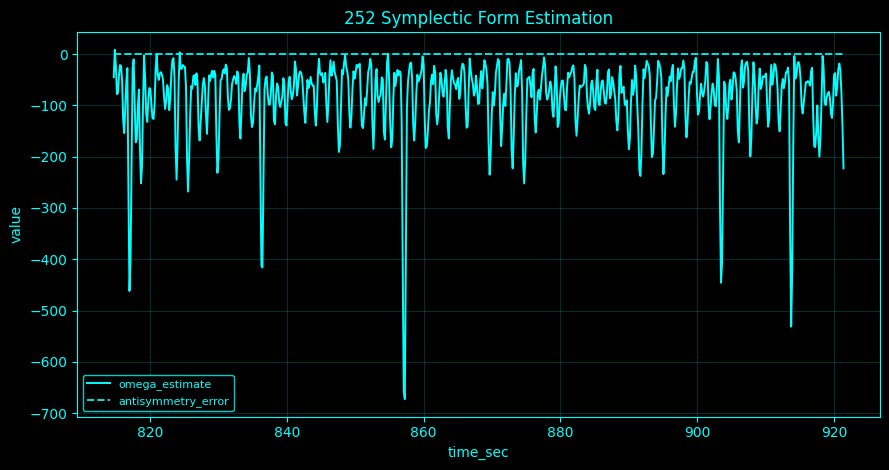

,time_sec,omega_estimate,antisymmetry_error
0,814.724,-45.158080,7.105427e-15
1,814.877,8.190311,0.000000e+00
2,815.030,-22.848880,3.552714e-15
3,815.183,-78.162961,1.421085e-14
4,815.336,-76.011880,1.421085e-14
...,...,...,...
693,920.749,-18.645804,3.552714e-15
694,920.902,-32.592830,7.105427e-15
695,921.055,-75.996450,0.000000e+00
696,921.208,-139.273066,0.000000e+00


In [262]:
u=dZ[:-1];v=dZ[1:];om=np.array([omega(a,b) for a,b in zip(u,v)]);anti=np.array([omega(a,b)+omega(b,a) for a,b in zip(u,v)]);scsave('252_symplectic_form_estimation',pd.DataFrame({'time_sec':tt[1:-1] if len(tt)>2 else tt[:len(om)],'omega_estimate':om[:max(0,len(tt)-2)] if len(tt)>2 else om,'antisymmetry_error':anti[:max(0,len(tt)-2)] if len(tt)>2 else anti}))


### Canonical coordinate geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> Darboux coordinates satisfy the canonical Poisson-bracket relations exactly. These identities define the coordinate chart and are independent of the particular EEG trajectory occupying it.<br><br>$$\{q_i,p_j\}=\delta_{ij},\qquad \{q_i,q_j\}=\{p_i,p_j\}=0.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


 max_qp_bracket_error  max_qq_bracket  max_pp_bracket
                  0.0             0.0             0.0


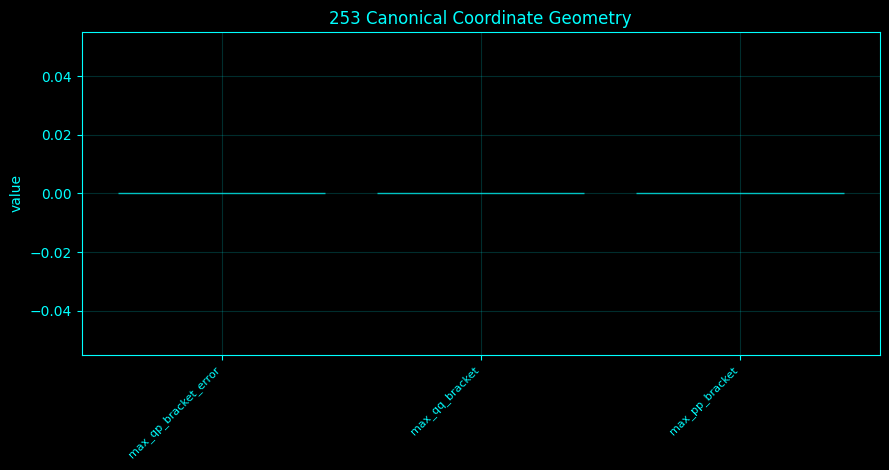

,max_qp_bracket_error,max_qq_bracket,max_pp_bracket
0,0.0,0.0,0.0


In [263]:
B=J6.copy();scsave('253_canonical_coordinate_geometry',pd.DataFrame({'max_qp_bracket_error':[np.max(np.abs(B[:3,3:]-np.eye(3)))],'max_qq_bracket':[np.max(np.abs(B[:3,:3]))],'max_pp_bracket':[np.max(np.abs(B[3:,3:]))]}))


### Hamiltonian phase-space geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> A fitted linear phase-space field zdot=A z is Hamiltonian precisely when A is a Hamiltonian matrix. Projecting A onto the Hamiltonian subspace gives the closest Frobenius linear Hamiltonian model and provides a residual diagnostic.<br><br>$$A^TJ+JA=0,\qquad A_H=\tfrac12(A+JA^TJ).$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 hamiltonian_residual  projection_relative_change
             1.319029                    0.659514


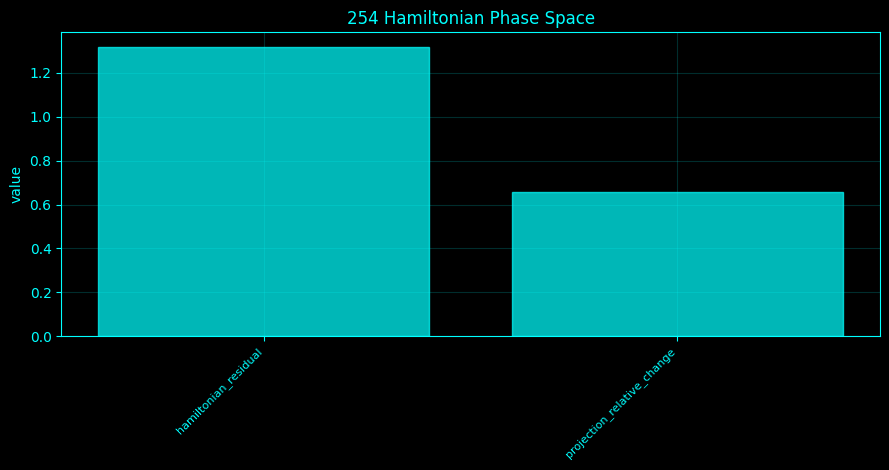

,hamiltonian_residual,projection_relative_change
0,1.319029,0.659514


In [264]:
Afit=fit_linear(Z6,dZ);AH=.5*(Afit+J6@Afit.T@J6);res=np.linalg.norm(Afit.T@J6+J6@Afit,'fro')/(np.linalg.norm(Afit,'fro')+EPS);scsave('254_hamiltonian_phase_space',pd.DataFrame({'hamiltonian_residual':[res],'projection_relative_change':[np.linalg.norm(Afit-AH,'fro')/(np.linalg.norm(Afit,'fro')+EPS)]}))


### Symplectic area of EEG trajectories


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> For each canonical (q_j,p_j) plane, the signed symplectic area enclosed by the sampled polygon is the line-integral area. Closing the sampled trajectory makes the quantity well defined for the observed loop.<br><br>$$\mathcal A_j=\frac12\oint(q_j\,dp_j-p_j\,dq_j)=\frac12\sum_i(q_{i,j}p_{i+1,j}-q_{i+1,j}p_{i,j}).$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 canonical_plane  signed_symplectic_area  absolute_area
               1             -263.008820     263.008820
               2             -335.740910     335.740910
               3             -312.173082     312.173082


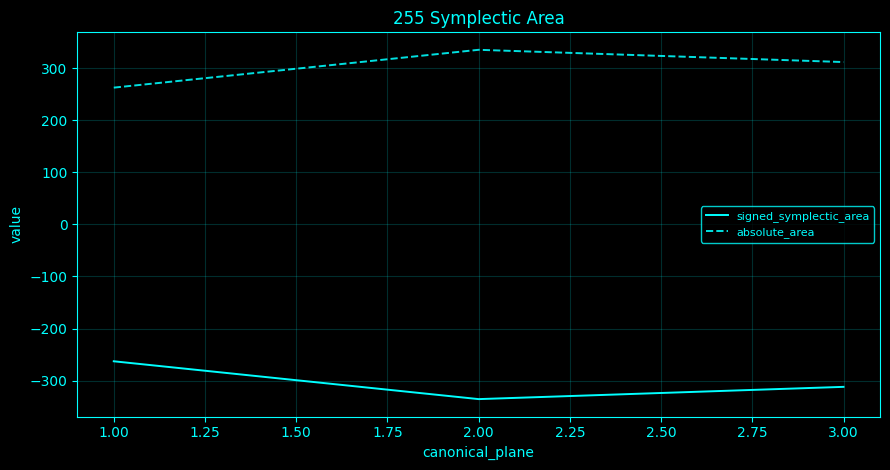

,canonical_plane,signed_symplectic_area,absolute_area
0,1,-263.008820,263.008820
1,2,-335.740910,335.740910
2,3,-312.173082,312.173082


In [265]:
rows=[]
for j in range(3):
 q=np.r_[Q[:,j],Q[0,j]];p=np.r_[P[:,j],P[0,j]];area=.5*np.sum(q[:-1]*p[1:]-q[1:]*p[:-1]);rows.append((j+1,area,abs(area)))
scsave('255_symplectic_area',pd.DataFrame(rows,columns=['canonical_plane','signed_symplectic_area','absolute_area']))


### Symplectic curvature proxy


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> A symplectic form alone does not determine a Riemannian curvature tensor. As an explicit proxy, the notebook measures the ordinary curvature of the phase-space trajectory under the compatible Euclidean metric in the chosen Darboux coordinates; it is therefore extrinsic and chart dependent.<br><br>$$\kappa=\frac{\sqrt{\|v\|^2\|a\|^2-(v\cdot a)^2}}{\|v\|^3}.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  compatible_metric_curve_curvature
  814.571                           0.061528
  814.724                           0.195690
  814.877                           0.597967
  815.030                           0.343932
  815.183                           0.849217
  815.336                           0.361314
  815.489                           0.968103
  815.642                           1.470564
  815.795                           1.149994
  815.948                           0.212831
  816.101                           1.175364
  816.254                           0.177126


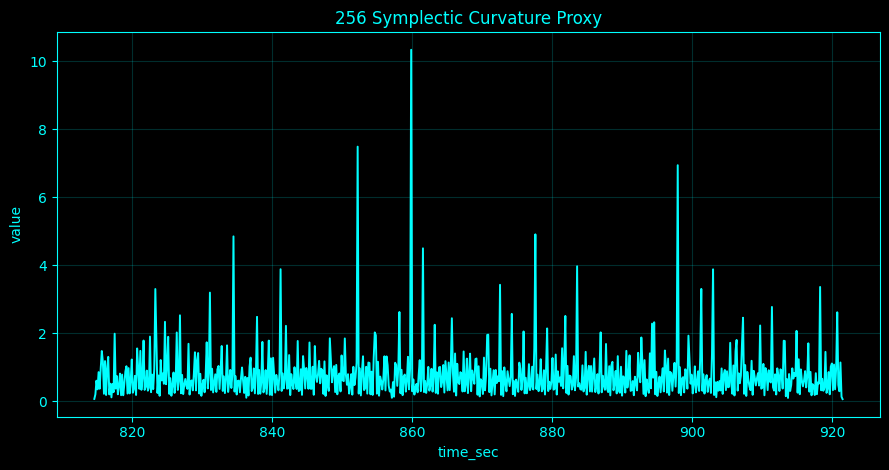

,time_sec,compatible_metric_curve_curvature
0,814.571,0.061528
1,814.724,0.195690
2,814.877,0.597967
3,815.030,0.343932
4,815.183,0.849217
...,...,...
695,920.902,0.473276
696,921.055,0.287508
697,921.208,1.133579
698,921.361,0.127134


In [266]:
vv=np.gradient(Z6,tt,axis=0);aa=np.gradient(vv,tt,axis=0);v2=np.sum(vv*vv,axis=1);a2=np.sum(aa*aa,axis=1);va=np.sum(vv*aa,axis=1);kap=np.sqrt(np.maximum(v2*a2-va*va,0))/(np.maximum(v2,EPS)**1.5);scsave('256_symplectic_curvature_proxy',pd.DataFrame({'time_sec':tt,'compatible_metric_curve_curvature':kap}))


### Symplectic eigenvalue analysis


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> Williamson symplectic eigenvalues of a positive-definite phase covariance are the positive moduli of the spectrum of iJΣ and occur in pairs. They are invariant under linear symplectic congruence.<br><br>$$\operatorname{spec}(iJ\Sigma)=\{\pm\nu_1,\ldots,\pm\nu_3\}.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 index  symplectic_eigenvalue
     1               0.180311
     2               0.725439
     3               1.567210


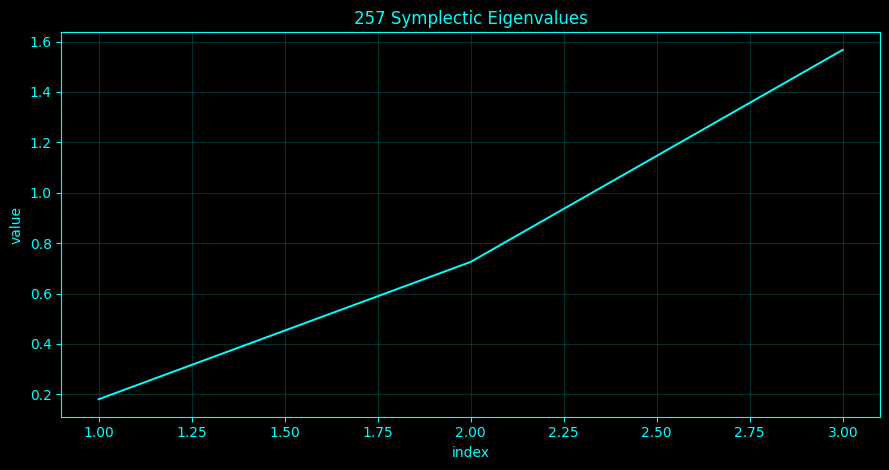

,index,symplectic_eigenvalue
0,1,0.180311
1,2,0.725439
2,3,1.567210


In [267]:
S6=phase_cov(Z6);nu=symplectic_eigs(S6);scsave('257_symplectic_eigenvalues',pd.DataFrame({'index':np.arange(1,4),'symplectic_eigenvalue':nu}))


### Hamiltonian energy geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> For the projected Hamiltonian linear field A_H, the symmetric matrix K=-J A_H defines a quadratic Hamiltonian H(z)=1/2 z^T K z under the convention zdot=J∇H. The observed variation of H quantifies how far the data trajectory is from an energy-conserving orbit of that fitted projected model.<br><br>$$A_H=JK,\quad K=-JA_H=K^T,\qquad H(z)=\tfrac12z^TKz.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  quadratic_hamiltonian  relative_energy_sd
  814.571              19.108480            0.862092
  814.724               7.640045            0.862092
  814.877               3.621083            0.862092
  815.030               8.618038            0.862092
  815.183              11.498988            0.862092
  815.336               2.966793            0.862092
  815.489               3.298251            0.862092
  815.642               3.613275            0.862092
  815.795              11.154766            0.862092
  815.948               8.429712            0.862092
  816.101              19.242614            0.862092
  816.254              12.100956            0.862092


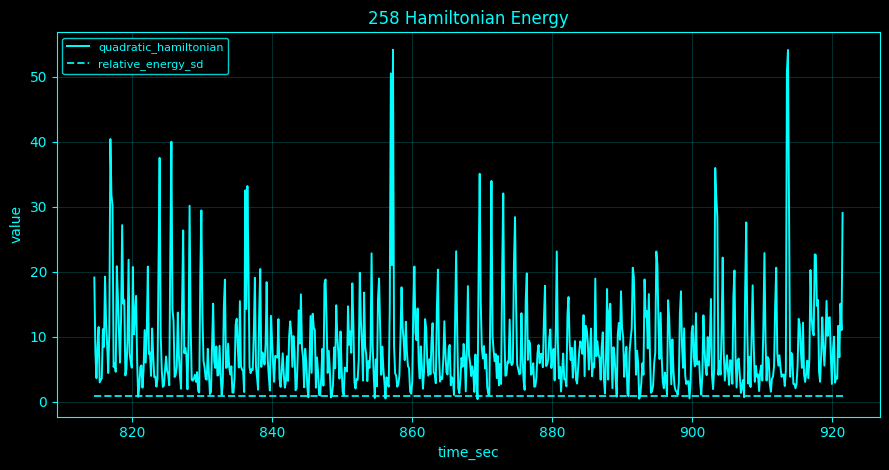

,time_sec,quadratic_hamiltonian,relative_energy_sd
0,814.571,19.108480,0.862092
1,814.724,7.640045,0.862092
2,814.877,3.621083,0.862092
3,815.030,8.618038,0.862092
4,815.183,11.498988,0.862092
...,...,...,...
695,920.902,11.674711,0.862092
696,921.055,6.852816,0.862092
697,921.208,15.078216,0.862092
698,921.361,11.012785,0.862092


In [268]:
Afit=fit_linear(Z6,dZ);AH=.5*(Afit+J6@Afit.T@J6);Kham=.5*((-J6@AH)+(-J6@AH).T);Hval=.5*np.einsum('ij,jk,ik->i',Z6,Kham,Z6);scsave('258_hamiltonian_energy',pd.DataFrame({'time_sec':tt,'quadratic_hamiltonian':Hval,'relative_energy_sd':[np.std(Hval)/(np.mean(np.abs(Hval))+EPS)]*len(Hval)}))


### Poisson bracket feature geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> The Poisson bracket associated with the canonical symplectic structure is {f,g}=∇f^T J∇g. For the quadratic position and momentum energies f=||q||²/2 and g=||p||²/2, the bracket reduces to q·p.<br><br>$$\{f,g\}=\nabla f^TJ\nabla g,\qquad \{\tfrac12\|q\|^2,\tfrac12\|p\|^2\}=q^Tp.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  poisson_qenergy_penergy
  814.571                -0.664020
  814.724                 2.591645
  814.877                 0.175917
  815.030                 0.832524
  815.183                -3.807536
  815.336                 0.160190
  815.489                 1.224687
  815.642                -0.435012
  815.795                 1.334795
  815.948                -0.044284
  816.101                -3.721744
  816.254                 0.516499


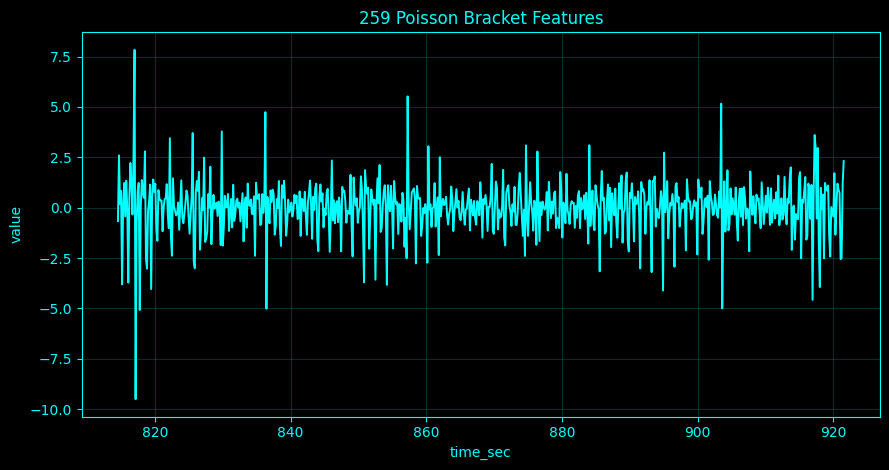

,time_sec,poisson_qenergy_penergy
0,814.571,-0.664020
1,814.724,2.591645
2,814.877,0.175917
3,815.030,0.832524
4,815.183,-3.807536
...,...,...
695,920.902,0.731603
696,921.055,-2.554690
697,921.208,-2.497163
698,921.361,1.183701


In [269]:
pb=np.sum(Q*P,axis=1);scsave('259_poisson_bracket_features',pd.DataFrame({'time_sec':tt,'poisson_qenergy_penergy':pb}))


### Phase-space volume preservation diagnostics


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> Hamiltonian flows preserve phase-space volume. For a fitted one-step linear map F, volume scaling is |det F|; exact preservation requires |det F|=1. This tests a local linear approximation rather than asserting a Hamiltonian law.<br><br>$$z_{k+1}\approx Fz_k,\qquad \frac{V_{k+1}}{V_k}=|\det F|.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 det_one_step_map  absolute_volume_scale  abs_absdet_minus_one
        -0.002015               0.002015              0.997985


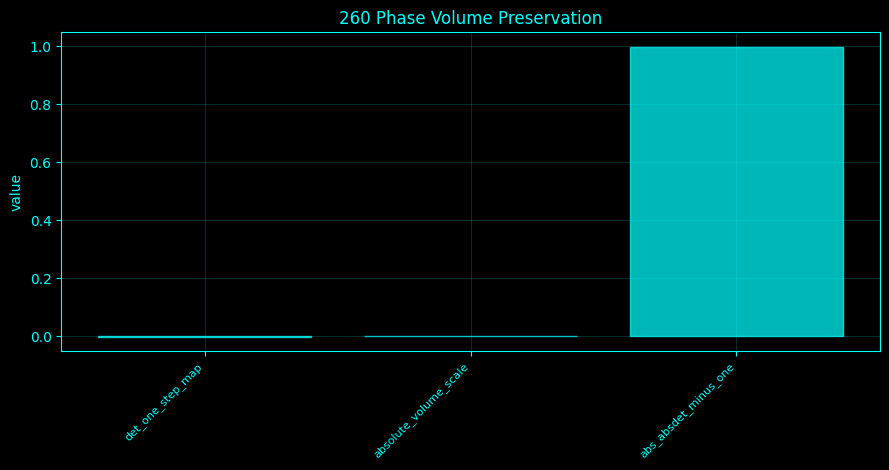

,det_one_step_map,absolute_volume_scale,abs_absdet_minus_one
0,-0.002015,0.002015,0.997985


In [270]:
Fmap=np.linalg.solve(Z6[:-1].T@Z6[:-1]+1e-5*np.eye(6),Z6[:-1].T@Z6[1:]).T;detF=np.linalg.det(Fmap);scsave('260_phase_volume_preservation',pd.DataFrame({'det_one_step_map':[detF],'absolute_volume_scale':[abs(detF)],'abs_absdet_minus_one':[abs(abs(detF)-1)]}))


### Liouville volume analysis


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> Liouville volume preservation for a continuous linear Hamiltonian field follows from zero divergence, tr(A)=0. The fitted field and its Hamiltonian projection are compared; the projected Hamiltonian matrix must have zero trace up to numerical precision.<br><br>$$\nabla\cdot(Az)=\operatorname{tr}A,\qquad A\ \text{Hamiltonian}\Rightarrow\operatorname{tr}A=0.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 fitted_divergence_trace  hamiltonian_projection_trace  hamiltonian_trace_abs
               -0.061708                  1.110223e-16           1.110223e-16


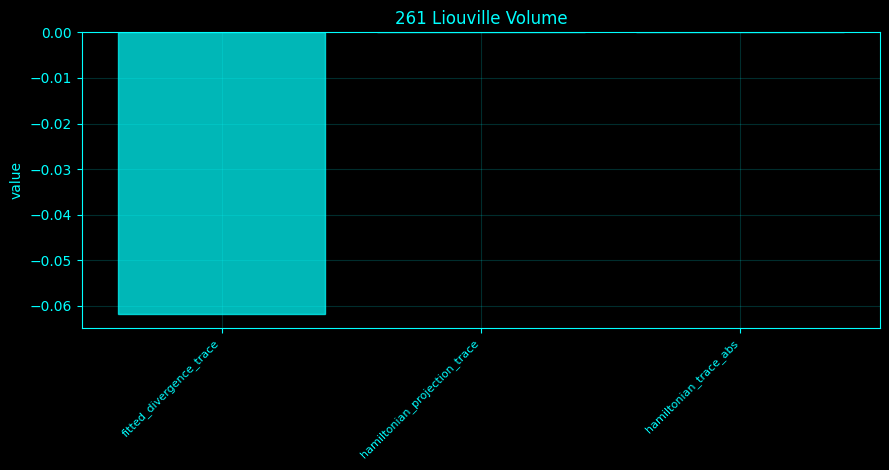

,fitted_divergence_trace,hamiltonian_projection_trace,hamiltonian_trace_abs
0,-0.061708,1.110223e-16,1.110223e-16


In [271]:
Afit=fit_linear(Z6,dZ);AH=.5*(Afit+J6@Afit.T@J6);scsave('261_liouville_volume',pd.DataFrame({'fitted_divergence_trace':[np.trace(Afit)],'hamiltonian_projection_trace':[np.trace(AH)],'hamiltonian_trace_abs':[abs(np.trace(AH))]}))


### Symplectic embedding comparison


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> Two canonical embeddings are compared while retaining the same q coordinates: derivative momenta p=dq/dt and analytic-quadrature momenta p=Hq. Their covariance symplectic spectra and mean form magnitudes quantify how strongly conclusions depend on the embedding choice.<br><br>$$z_D=(q,\dot q),\qquad z_H=(q,\mathcal H q).$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 index  derivative_embedding_nu  hilbert_embedding_nu  absolute_difference
     1                 0.180311              0.266575             0.086263
     2                 0.725439              1.001470             0.276031
     3                 1.567210              1.736247             0.169036


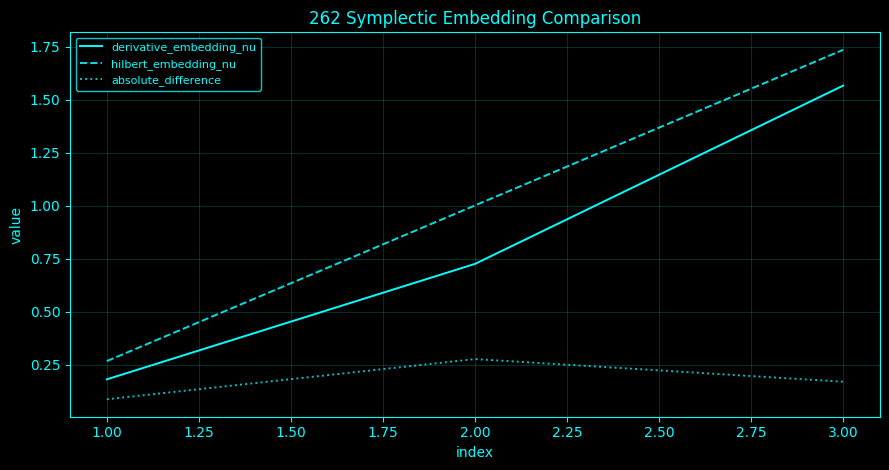

,index,derivative_embedding_nu,hilbert_embedding_nu,absolute_difference
0,1,0.180311,0.266575,0.086263
1,2,0.725439,1.001470,0.276031
2,3,1.567210,1.736247,0.169036


In [272]:
PH=np.imag(signal.hilbert(Q,axis=0));PH/=np.std(PH,axis=0,keepdims=True)+EPS;ZH=np.c_[Q,PH];nuD=symplectic_eigs(phase_cov(Z6));nuH=symplectic_eigs(phase_cov(ZH));rows=[(i+1,nuD[i],nuH[i],abs(nuD[i]-nuH[i])) for i in range(3)];scsave('262_symplectic_embedding_comparison',pd.DataFrame(rows,columns=['index','derivative_embedding_nu','hilbert_embedding_nu','absolute_difference']))


### Symplectic manifold fingerprints


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> Each channel analytic phase portrait provides a covariance-ellipse area, one-step area-preservation error, and major-axis orientation. These chart-specific descriptors form a comparable symplectic fingerprint.<br><br>$$f_c=(\pi\sqrt{\det\Sigma_c},\ |\det F_c-1|,\ \theta_c).$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


channel  ellipse_area  area_preservation_error  major_axis_angle
    Fp1      3.073533                 0.571004          0.000000
    Fpz      3.077326                 0.388890          0.000000
    Fp2      3.119546                 0.189256         -3.141593
     F7      3.196886                 0.651417          0.000000
     F3      3.040108                 0.632899          0.000000
     Fz      3.126394                 0.715171          0.000000
     F4      3.121317                 0.476421          0.000000
     F8      3.192348                 0.613611         -3.141593
    FC5      3.179344                 0.697817          0.000000
    FC1      3.117543                 0.446906          0.000000
    FC2      3.164438                 0.713582          0.000000
    FC6      3.148715                 0.283148         -3.141593


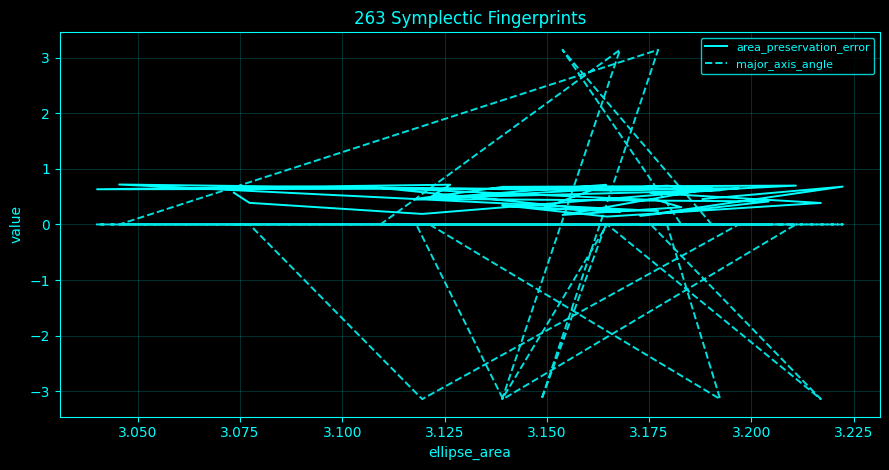

,channel,ellipse_area,area_preservation_error,major_axis_angle
0,Fp1,3.073533,0.571004,0.000000
1,Fpz,3.077326,0.388890,0.000000
2,Fp2,3.119546,0.189256,-3.141593
3,F7,3.196886,0.651417,0.000000
4,F3,3.040108,0.632899,0.000000
5,Fz,3.126394,0.715171,0.000000
6,F4,3.121317,0.476421,0.000000
7,F8,3.192348,0.613611,-3.141593
8,FC5,3.179344,0.697817,0.000000
9,FC1,3.117543,0.446906,0.000000


In [273]:
rows=[]
for j in range(nC):
 x=EEG_STD[si,j];h=np.imag(signal.hilbert(x));Y=np.c_[x,h];S=np.cov(Y,rowvar=False);F=fit_linear(Y[:-1],Y[1:]);w,V=np.linalg.eigh(S);v=V[:,np.argmax(w)];rows.append((eeg_channel_names[j],np.pi*np.sqrt(max(np.linalg.det(S),0)),abs(np.linalg.det(F)-1),np.arctan2(v[1],v[0])))
scsave('263_symplectic_fingerprints',pd.DataFrame(rows,columns=['channel','ellipse_area','area_preservation_error','major_axis_angle']))


### Contact geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> The standard five-dimensional Darboux contact chart uses α=dz-p1dq1-p2dq2. Its defining condition is α∧(dα)^2 nonzero. Contact geometry is odd-dimensional and is not a symplectic structure on the same space.<br><br>$$\alpha=dz-p_1dq_1-p_2dq_2,\qquad \alpha\wedge(d\alpha)^2\neq0.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  alpha_velocity
  814.571      -40.700730
  814.724       -5.577979
  814.877       -2.467132
  815.030       -4.158757
  815.183      -13.492711
  815.336       -0.587329
  815.489       -2.384885
  815.642       -4.021776
  815.795       -4.765868
  815.948        0.469932
  816.101      -19.991111
  816.254       -0.319019


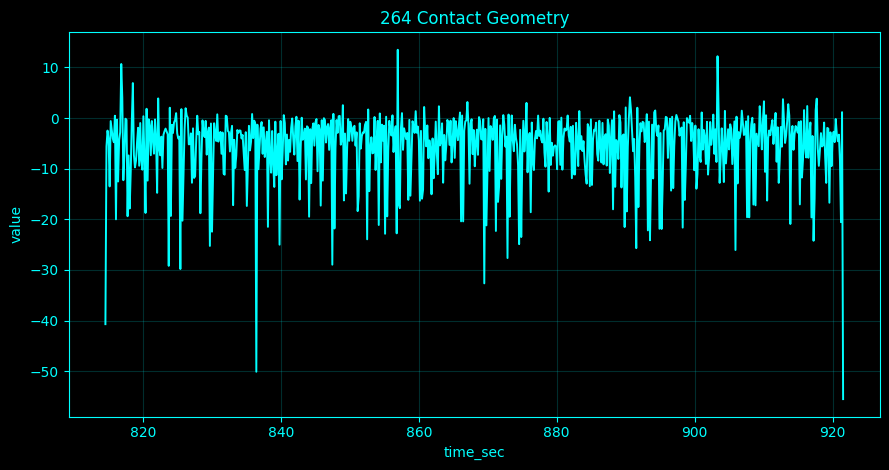

,time_sec,alpha_velocity
0,814.571,-40.700730
1,814.724,-5.577979
2,814.877,-2.467132
3,815.030,-4.158757
4,815.183,-13.492711
...,...,...
695,920.902,-3.273621
696,921.055,-8.444561
697,921.208,-20.550380
698,921.361,1.173543


In [274]:
av=np.array([contact_alpha_vel(x,v) for x,v in zip(C5,dC5)]);scsave('264_contact_geometry',pd.DataFrame({'time_sec':tt,'alpha_velocity':av}))


### Contact form proxy for EEG phase-amplitude states


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> A phase-amplitude contact proxy is constructed from the global analytic signal using q=unwrapped phase, p=standardized amplitude, and z=standardized log-amplitude. Evaluating α=dz-pdq on the trajectory measures departure from the horizontal contact distribution for this explicitly chosen chart.<br><br>$$\alpha(\dot\gamma)=\dot z-p\dot q.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  alpha_velocity_proxy    phase  amplitude_z
  814.571              2.964647 1.938202     0.659080
  814.724             -1.077349 0.958995     0.364143
  814.877              2.060986 1.071559    -0.204970
  815.030              3.760141 0.863282     1.529510
  815.183             -2.939008 0.916706     1.137682
  815.336             -2.728302 1.697474     1.640119
  815.489             -5.774199 0.619687    -0.593800
  815.642              1.475318 0.998452    -0.406568
  815.795              3.079534 0.027517     0.131901
  815.948             -0.824249 0.853008     0.792389
  816.101             -4.788228 0.958816     0.870700
  816.254             -3.176235 2.380318     0.569449


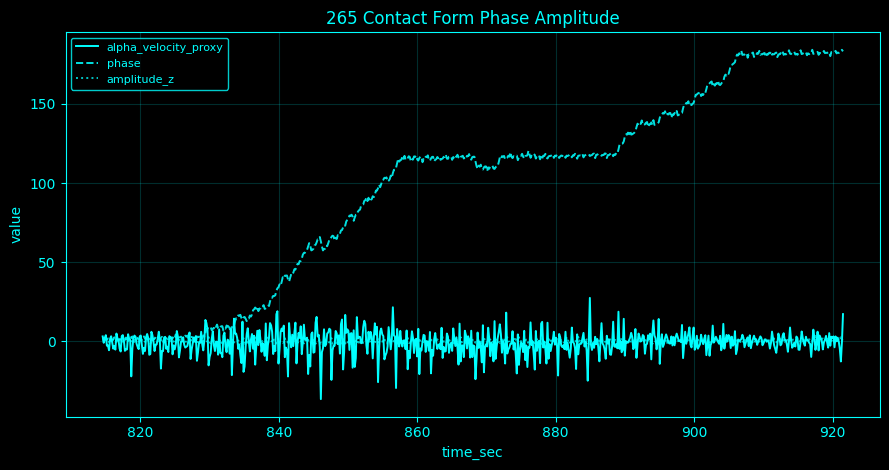

,time_sec,alpha_velocity_proxy,phase,amplitude_z
0,814.571,2.964647,1.938202,0.659080
1,814.724,-1.077349,0.958995,0.364143
2,814.877,2.060986,1.071559,-0.204970
3,815.030,3.760141,0.863282,1.529510
4,815.183,-2.939008,0.916706,1.137682
...,...,...,...,...
695,920.902,-0.143882,182.275983,2.272727
696,921.055,-4.928701,182.926196,1.595663
697,921.208,-12.872472,183.241063,2.358226
698,921.361,-0.758571,184.258302,0.200680


In [275]:
ga=signal.hilbert(EEG_STD.mean(1));idx=si;qq=np.unwrap(np.angle(ga[idx]));pp=np.abs(ga[idx]);pp=(pp-pp.mean())/(pp.std()+EPS);zz=np.log(np.abs(ga[idx])+EPS);zz=(zz-zz.mean())/(zz.std()+EPS);dqq=np.gradient(qq,tt);dzz=np.gradient(zz,tt);aa=dzz-pp*dqq;scsave('265_contact_form_phase_amplitude',pd.DataFrame({'time_sec':tt,'alpha_velocity_proxy':aa,'phase':qq,'amplitude_z':pp}))


### Reeb vector field proxy


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> For α=dz-pdq the exact Reeb vector field is R=∂z because α(R)=1 and i_R dα=0. The data-dependent quantity is only the alignment of observed phase-amplitude velocity with that fixed Reeb direction.<br><br>$$\alpha(R)=1,\quad \iota_Rd\alpha=0,\quad R=\partial_z.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A derivative measures how quickly one quantity changes when another changes. Partial derivatives are used when a function depends on several variables.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  abs_reeb_alignment
  814.571            0.184322
  814.724            0.466399
  814.877            0.486028
  815.030            0.560086
  815.183            0.058969
  815.336            0.601288
  815.489            0.530026
  815.642            0.594336
  815.795            0.607277
  815.948            0.378247
  816.101            0.087367
  816.254            0.613484


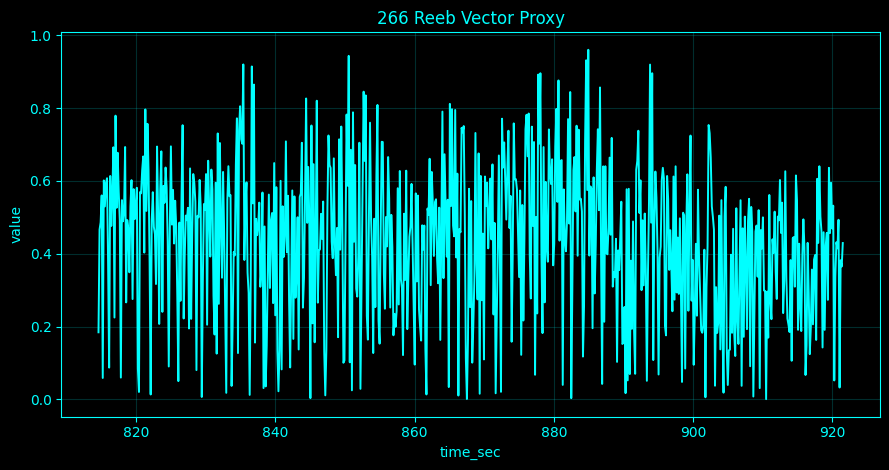

,time_sec,abs_reeb_alignment
0,814.571,0.184322
1,814.724,0.466399
2,814.877,0.486028
3,815.030,0.560086
4,815.183,0.058969
...,...,...
695,920.902,0.493273
696,921.055,0.032763
697,921.208,0.382115
698,921.361,0.365022


In [276]:
YY=np.c_[qq,pp,zz];dYY=np.gradient(YY,tt,axis=0);align=np.abs(dYY[:,2])/(np.linalg.norm(dYY,axis=1)+EPS);scsave('266_reeb_vector_proxy',pd.DataFrame({'time_sec':tt,'abs_reeb_alignment':align}))


### Contact Hamiltonian geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> Using the convention α(X_H)=H and i_X dα=-dH+(R H)α for α=dz-pdq, a contact Hamiltonian H(q,p,z) generates X_H=(-H_p, H_q+pH_z, H-pH_p). The notebook uses H=(q²+p²+z²)/2 as a transparent reference field and compares its direction with the observed trajectory.<br><br>$$X_H=(-H_p)\partial_q+(H_q+pH_z)\partial_p+(H-pH_p)\partial_z.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A derivative measures how quickly one quantity changes when another changes. Partial derivatives are used when a function depends on several variables.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  reference_contact_H  velocity_field_cosine
  814.571             2.359640              -0.132856
  814.724             0.669267              -0.561206
  814.877             0.598452               0.970635
  815.030             2.244814               0.744080
  815.183             1.562668              -0.356569
  815.336             3.548344              -0.776014
  815.489             0.421667              -0.844137
  815.642             0.587924               0.580578
  815.795             0.075880               0.661938
  815.948             1.002852               0.245903
  816.101             1.201038              -0.582233
  816.254             3.220202              -0.954775


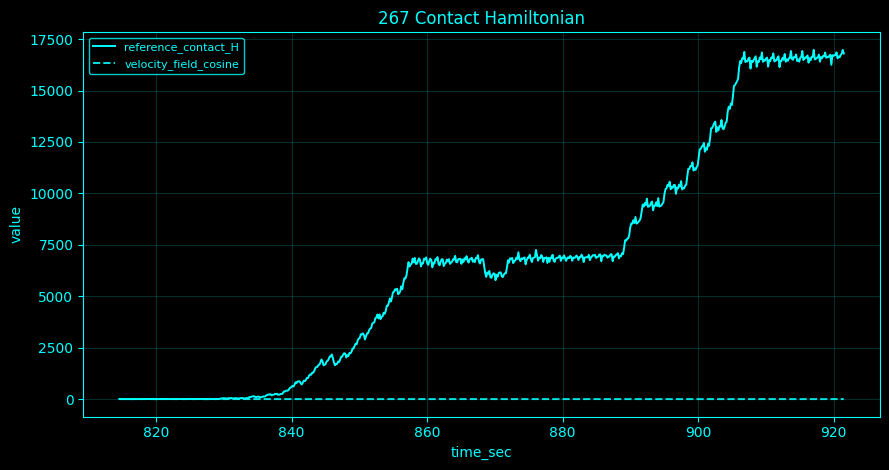

,time_sec,reference_contact_H,velocity_field_cosine
0,814.571,2.359640,-0.132856
1,814.724,0.669267,-0.561206
2,814.877,0.598452,0.970635
3,815.030,2.244814,0.744080
4,815.183,1.562668,-0.356569
...,...,...,...
695,920.902,16615.963330,0.502594
696,921.055,16733.008062,0.033641
697,921.208,16792.585862,-0.389619
698,921.361,16975.668369,-0.375056


In [277]:
q0,p0,z0=qq,pp,zz;Hc=.5*(q0*q0+p0*p0+z0*z0);XH=np.c_[-p0,q0+p0*z0,Hc-p0*p0];cos=np.sum(dYY*XH,axis=1)/(np.linalg.norm(dYY,axis=1)*np.linalg.norm(XH,axis=1)+EPS);scsave('267_contact_hamiltonian',pd.DataFrame({'time_sec':tt,'reference_contact_H':Hc,'velocity_field_cosine':cos}))


### Contact volume features


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> For the three-dimensional Darboux form α=dz-pdq, the canonical contact volume form is α∧dα=dz∧dq∧dp up to orientation. The coefficient is fixed by the chart, so the notebook separately reports the sample covariance-volume occupied by the phase-amplitude trajectory.<br><br>$$\alpha\wedge d\alpha=dz\wedge dq\wedge dp.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 canonical_contact_volume_density  sample_covariance_determinant  sample_volume_scale
                              1.0                   2.404606e+06          1550.679227


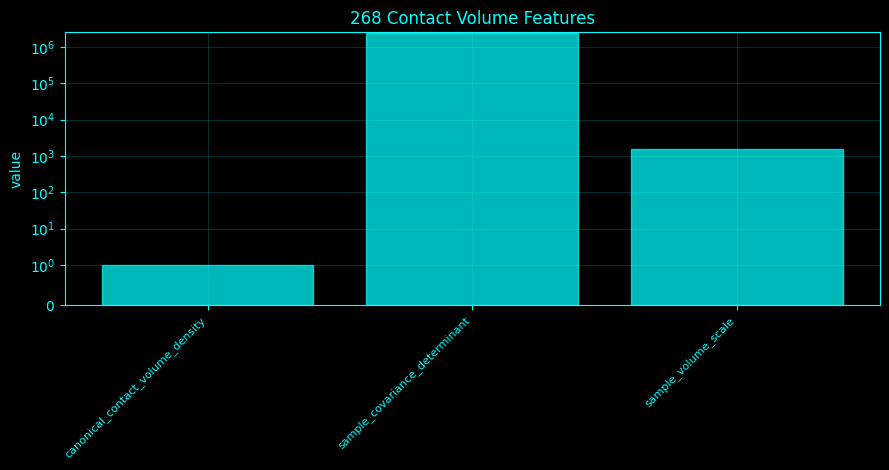

,canonical_contact_volume_density,sample_covariance_determinant,sample_volume_scale
0,1.0,2.404606e+06,1550.679227


In [278]:
occ=np.linalg.det(reg(np.cov(YY,rowvar=False)));scsave('268_contact_volume_features',pd.DataFrame({'canonical_contact_volume_density':[1.0],'sample_covariance_determinant':[occ],'sample_volume_scale':[np.sqrt(max(occ,0))]}))


### Phase-amplitude contact geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> Each channel is embedded by its analytic phase q, amplitude p, and log-amplitude z in the same contact chart. The RMS value of α(dotγ) yields a channel-wise phase-amplitude contact descriptor.<br><br>$$q=\arg a(t),\quad p=|a(t)|,\quad z=\log|a(t)|,\quad \alpha=dz-pdq.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


channel  rms_alpha_velocity  mean_abs_alpha_velocity
    Fp1            6.231316                 3.855029
    Fpz            4.766151                 3.022611
    Fp2            3.035803                 2.010469
     F7            6.353199                 4.517215
     F3            6.933118                 4.811825
     Fz            7.196430                 5.230631
     F4            5.630595                 3.971910
     F8            6.352824                 4.581964
    FC5            8.657089                 6.210928
    FC1            4.946371                 3.334794
    FC2            7.706047                 5.566125
    FC6            3.787896                 2.705934


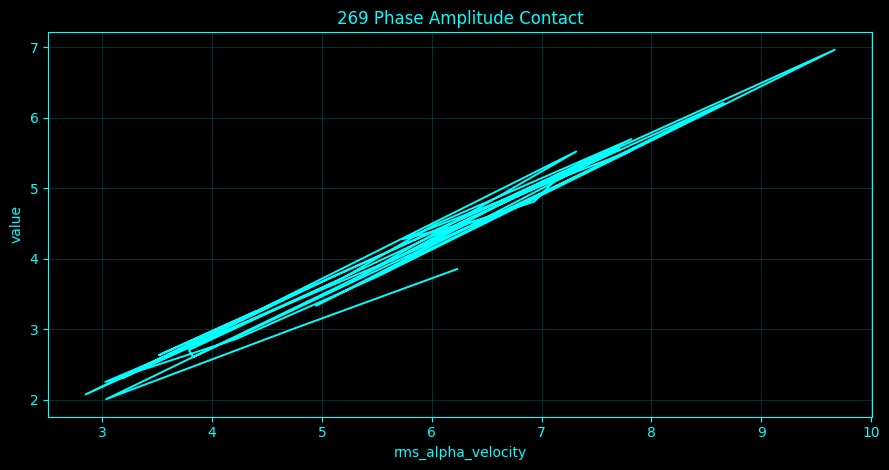

,channel,rms_alpha_velocity,mean_abs_alpha_velocity
0,Fp1,6.231316,3.855029
1,Fpz,4.766151,3.022611
2,Fp2,3.035803,2.010469
3,F7,6.353199,4.517215
4,F3,6.933118,4.811825
5,Fz,7.196430,5.230631
6,F4,5.630595,3.971910
7,F8,6.352824,4.581964
8,FC5,8.657089,6.210928
9,FC1,4.946371,3.334794


In [279]:
rows=[]
for j in range(nC):
 an=signal.hilbert(EEG_STD[:,j])[si];q=np.unwrap(np.angle(an));p=np.abs(an);p=(p-p.mean())/(p.std()+EPS);z=np.log(np.abs(an)+EPS);z=(z-z.mean())/(z.std()+EPS);aa=np.gradient(z,tt)-p*np.gradient(q,tt);rows.append((eeg_channel_names[j],np.sqrt(np.mean(aa*aa)),np.mean(np.abs(aa))))
scsave('269_phase_amplitude_contact',pd.DataFrame(rows,columns=['channel','rms_alpha_velocity','mean_abs_alpha_velocity']))


### Dissipative contact geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> Contact Hamiltonian systems can model dissipative dynamics because contact volume need not be preserved. As a data proxy, a linear flow is fitted to the three-dimensional phase-amplitude contact state and its divergence tr(A) is reported; negative trace indicates local linear volume contraction in this chosen chart.<br><br>$$\dot y\approx Ay,\qquad \nabla\cdot\dot y=\operatorname{tr}A.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 linear_flow_divergence  volume_contraction_indicator
               0.044477                             0


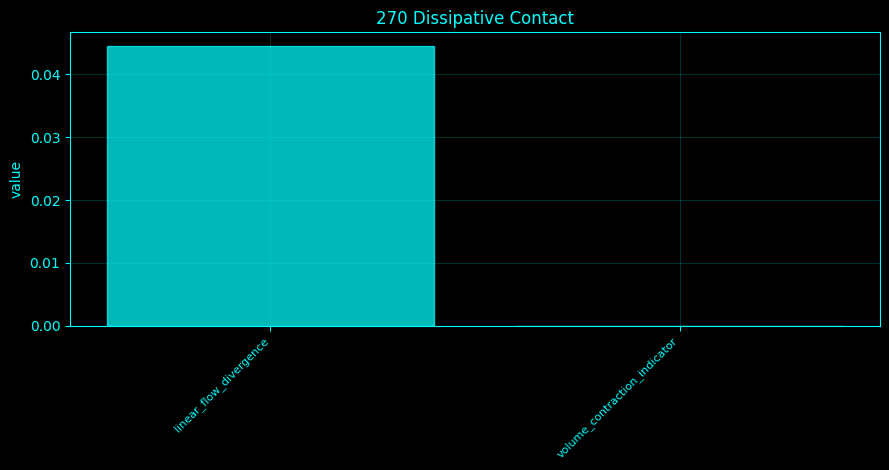

,linear_flow_divergence,volume_contraction_indicator
0,0.044477,0


In [280]:
Ac=fit_linear(YY,np.gradient(YY,tt,axis=0));scsave('270_dissipative_contact',pd.DataFrame({'linear_flow_divergence':[np.trace(Ac)],'volume_contraction_indicator':[int(np.trace(Ac)<0)]}))


### Event-locked contact-geometry changes


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> Internal high-envelope landmarks are reference times rather than experimental markers. The notebook compares |α(dotγ)| before and after each selected landmark.<br><br>$$\Delta_\alpha=\langle|\alpha(\dot\gamma)|\rangle_{post}-\langle|\alpha(\dot\gamma)|\rangle_{pre}.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 landmark_time  pre_abs_alpha  post_abs_alpha
       817.019       6.992812        8.575923
       825.587       5.706608        5.445307
       836.296       5.596811        9.829426
       851.443       6.453629        5.286911
       857.103       6.764047        6.682598
       869.649       6.444033        6.611638
       878.982       5.574855        6.045219
       903.461       5.055782        6.712892
       913.711       2.907967        4.938654
       919.219       6.404261        5.559933


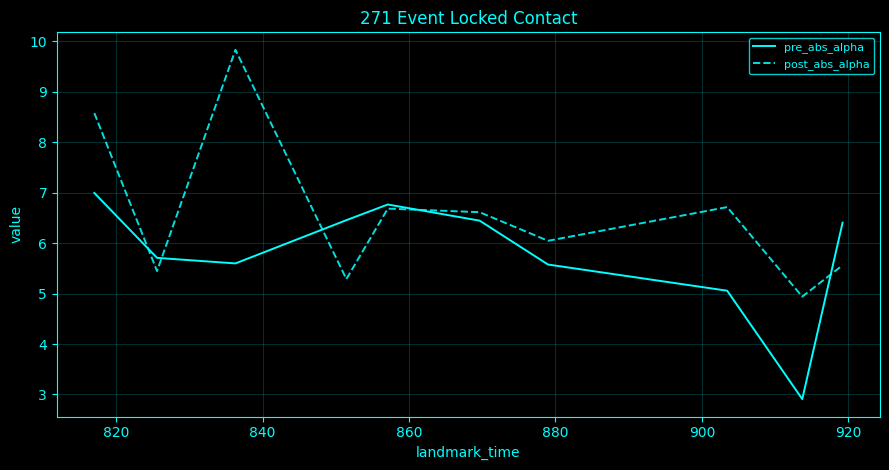

,landmark_time,pre_abs_alpha,post_abs_alpha
0,817.019,6.992812,8.575923
1,825.587,5.706608,5.445307
2,836.296,5.596811,9.829426
3,851.443,6.453629,5.286911
4,857.103,6.764047,6.682598
5,869.649,6.444033,6.611638
6,878.982,5.574855,6.045219
7,903.461,5.055782,6.712892
8,913.711,2.907967,4.938654
9,919.219,6.404261,5.559933


In [281]:
env=np.linalg.norm(Q,axis=1);pk,_=signal.find_peaks(env,distance=max(5,len(env)//20),prominence=np.std(env)*.35);pk=pk[np.argsort(env[pk])[-min(10,len(pk)):]] if len(pk) else np.array([],int);av=np.array([contact_alpha_vel(x,v) for x,v in zip(C5,dC5)]);rows=[]
for k in np.sort(pk):
 w=max(4,len(av)//80);pre=np.abs(av[max(0,k-w):k]);post=np.abs(av[k:min(len(av),k+w)]);rows.append((tt[k],np.mean(pre) if len(pre) else np.nan,np.mean(post) if len(post) else np.nan))
scsave('271_event_locked_contact',pd.DataFrame(rows,columns=['landmark_time','pre_abs_alpha','post_abs_alpha']))


### Complex and Hermitian geometry extensions


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> Analytic EEG samples are complex vectors, while windowed analytic covariances are Hermitian positive definite after regularization. This permits projective, Kähler, unitary-invariant, and complex-subspace geometry without discarding phase.<br><br>$$z(t)\in\mathbb C^n,\qquad C=C^*\succ0.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 n_projective_states  n_hpd_windows  mean_hermiticity_error
                 700             42                     0.0


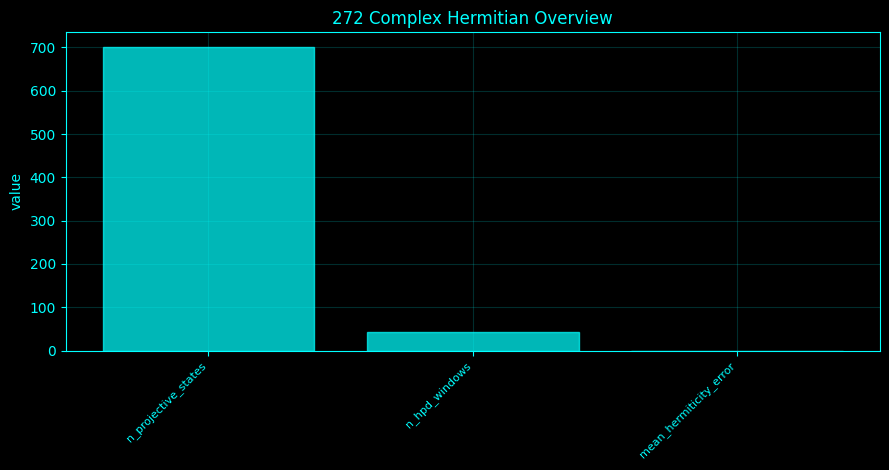

,n_projective_states,n_hpd_windows,mean_hermiticity_error
0,700,42,0.0


In [282]:
scsave('272_complex_hermitian_overview',pd.DataFrame({'n_projective_states':[len(CP)],'n_hpd_windows':[len(HC)],'mean_hermiticity_error':[np.mean([np.linalg.norm(A-A.conj().T) for A in HC])]}))


### Complex projective geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> Complex projective space identifies unit vectors that differ only by a common complex phase. Projective geometry therefore retains relative channel phase while quotienting a global phase offset.<br><br>$$\mathbb{CP}^{n-1}=\{z\in\mathbb C^n:\|z\|=1\}/U(1).$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


 time_sec  fubini_study_step
  814.724           0.426483
  814.877           0.089133
  815.030           0.244998
  815.183           0.127755
  815.336           0.431046
  815.489           0.609637
  815.642           0.276499
  815.795           0.437791
  815.948           0.424612
  816.101           0.118755
  816.254           0.638804
  816.407           0.704515


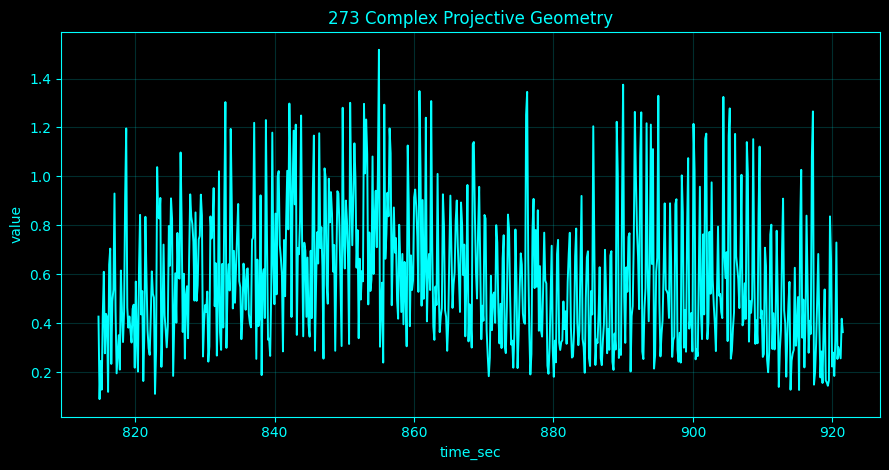

,time_sec,fubini_study_step
0,814.724,0.426483
1,814.877,0.089133
2,815.030,0.244998
3,815.183,0.127755
4,815.336,0.431046
...,...,...
694,920.902,0.301302
695,921.055,0.277633
696,921.208,0.255899
697,921.361,0.417881


In [283]:
step=np.array([fsdist(CP[i],CP[i+1]) for i in range(len(CP)-1)]);scsave('273_complex_projective_geometry',pd.DataFrame({'time_sec':CPT[1:],'fubini_study_step':step}))


### Fubini-Study distance


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> For normalized representatives, the Fubini-Study distance is arccos of the magnitude of the Hermitian inner product. The magnitude makes the result invariant to independent global-phase choices.<br><br>$$d_{FS}([z],[w])=\arccos|z^*w|.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


/tmp/ipykernel_142206/2057821722.py:28: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.set_facecolor(BG); ax.grid(grid,alpha=.18,color=ACCENT); ax.tick_params(colors=ACCENT)


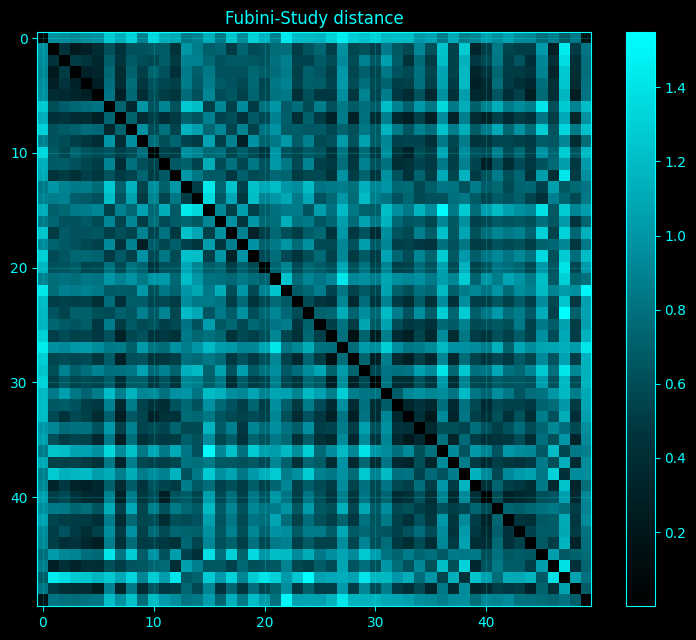

array([[4.78232102e-07, 9.59192523e-01, 9.40934150e-01, ...,
        6.87670557e-01, 8.27671646e-01, 1.72334968e-01],
       [9.59192523e-01, 7.89058345e-07, 4.47524159e-01, ...,
        1.44062626e+00, 4.99448020e-01, 8.21585448e-01],
       [9.40934150e-01, 4.47524159e-01, 8.41618851e-07, ...,
        1.37185914e+00, 4.27870858e-01, 7.91128219e-01],
       ...,
       [6.87670557e-01, 1.44062626e+00, 1.37185914e+00, ...,
        1.03528224e-06, 1.06296700e+00, 8.00941016e-01],
       [8.27671646e-01, 4.99448020e-01, 4.27870858e-01, ...,
        1.06296700e+00, 7.69252151e-07, 6.84564518e-01],
       [1.72334968e-01, 8.21585448e-01, 7.91128219e-01, ...,
        8.00941016e-01, 6.84564518e-01, 4.74269106e-07]])

In [284]:
m=min(50,len(CP));jj=np.unique(np.linspace(0,len(CP)-1,m).round().astype(int));D=np.array([[fsdist(CP[i],CP[j]) for j in jj] for i in jj]);emit_matrix('274_fubini_study_distance','Fubini-Study distance',D,[f'{CPT[i]:.2f}' for i in jj])


### Complex covariance geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> Windowed complex analytic-signal covariance C=Z*Z/N is Hermitian and becomes positive definite after regularization. Its eigenvalues describe complex covariance shape while preserving phase-sensitive cross terms.<br><br>$$C=\frac1N Z^*Z,\qquad C=C^*\succ0.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 time_sec     logdet  min_eigenvalue  max_eigenvalue
  815.571  -4.974053        0.125115       42.999812
  818.071  -3.167303        0.121326       37.753308
  820.571  -9.577407        0.054177       16.588495
  823.071  -9.993344        0.051275       16.527760
  825.571 -11.215787        0.043577       13.566348
  828.071 -12.653838        0.034825        9.767413
  830.571 -12.629586        0.032598        9.083797
  833.071 -12.983900        0.034119        9.635061
  835.571  -7.066434        0.056434       12.076356
  838.071 -13.710448        0.032158        9.105793
  840.571 -13.817242        0.029071        6.252462
  843.071 -14.598567        0.024230        5.767738


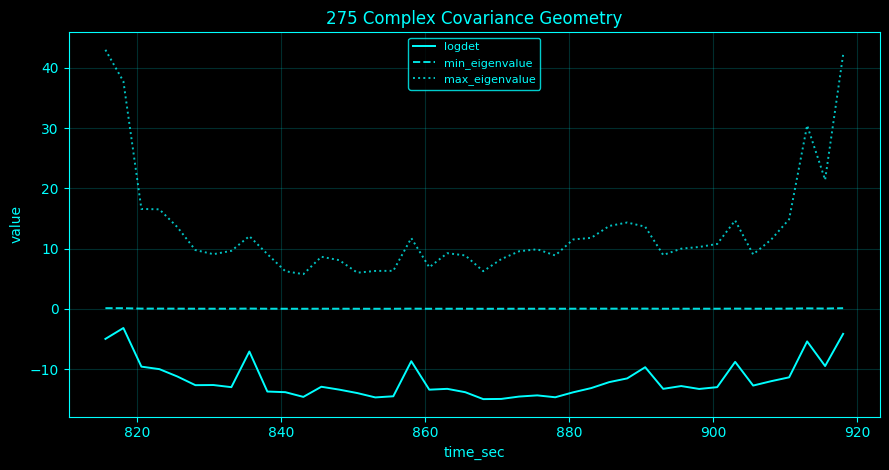

,time_sec,logdet,min_eigenvalue,max_eigenvalue
0,815.571,-4.974053,0.125115,42.999812
1,818.071,-3.167303,0.121326,37.753308
2,820.571,-9.577407,0.054177,16.588495
3,823.071,-9.993344,0.051275,16.527760
4,825.571,-11.215787,0.043577,13.566348
5,828.071,-12.653838,0.034825,9.767413
6,830.571,-12.629586,0.032598,9.083797
7,833.071,-12.983900,0.034119,9.635061
8,835.571,-7.066434,0.056434,12.076356
9,838.071,-13.710448,0.032158,9.105793


In [285]:
rows=[]
for t0,C in zip(HT,HC):rows.append((t0,np.linalg.slogdet(C)[1].real,np.min(np.linalg.eigvalsh(C)),np.max(np.linalg.eigvalsh(C))))
scsave('275_complex_covariance_geometry',pd.DataFrame(rows,columns=['time_sec','logdet','min_eigenvalue','max_eigenvalue']))


### Hermitian SPD geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> The affine-invariant metric on Hermitian positive-definite matrices is the complex analogue of the real SPD AIRM. Congruence whitening followed by the Hermitian matrix logarithm gives the geodesic distance.<br><br>$$d(C_1,C_2)=\|\log(C_1^{-1/2}C_2C_1^{-1/2})\|_F.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  hpd_airm_step
  818.071       4.094424
  820.571       4.044055
  823.071       3.441830
  825.571       2.835887
  828.071       2.205507
  830.571       2.359742
  833.071       2.381253
  835.571       4.502688
  838.071       4.532624
  840.571       3.452338
  843.071       3.178636
  845.571       3.119846


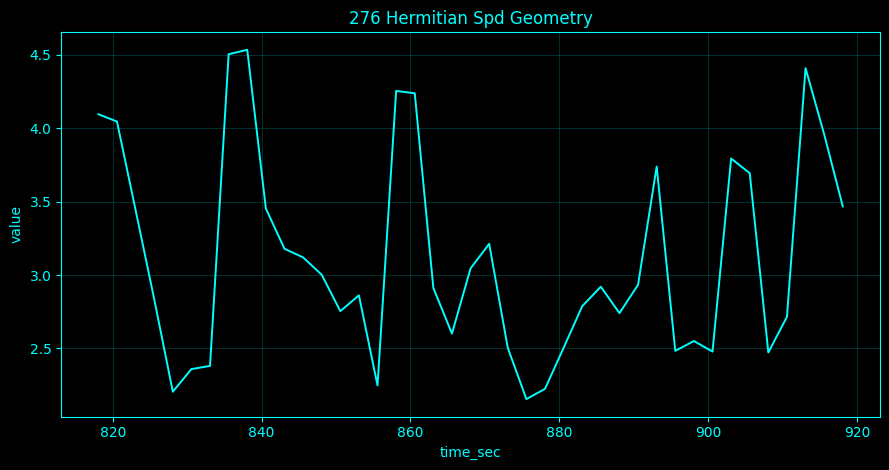

,time_sec,hpd_airm_step
0,818.071,4.094424
1,820.571,4.044055
2,823.071,3.441830
3,825.571,2.835887
4,828.071,2.205507
5,830.571,2.359742
6,833.071,2.381253
7,835.571,4.502688
8,838.071,4.532624
9,840.571,3.452338


In [286]:
d=[hairm(HC[i],HC[i+1]) for i in range(len(HC)-1)];scsave('276_hermitian_spd_geometry',pd.DataFrame({'time_sec':HT[1:],'hpd_airm_step':d}))


### Kähler potential estimation


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> In an affine chart of complex projective space with normalized representative z and z_0 nonzero, the Fubini-Study Kähler potential is K=log(1+||w||²)=-log|z_0|², where w=z_rest/z_0. The potential is chart dependent even though the metric is intrinsic.<br><br>$$K(w,\bar w)=\log(1+\|w\|^2).$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  FS_kahler_potential_chart0
  814.571                    3.616172
  814.724                    2.762709
  814.877                    2.758750
  815.030                    2.604989
  815.183                    2.515019
  815.336                    4.068086
  815.489                    2.055896
  815.642                    2.425324
  815.795                    1.961700
  815.948                    2.357947
  816.101                    2.448519
  816.254                    3.752369


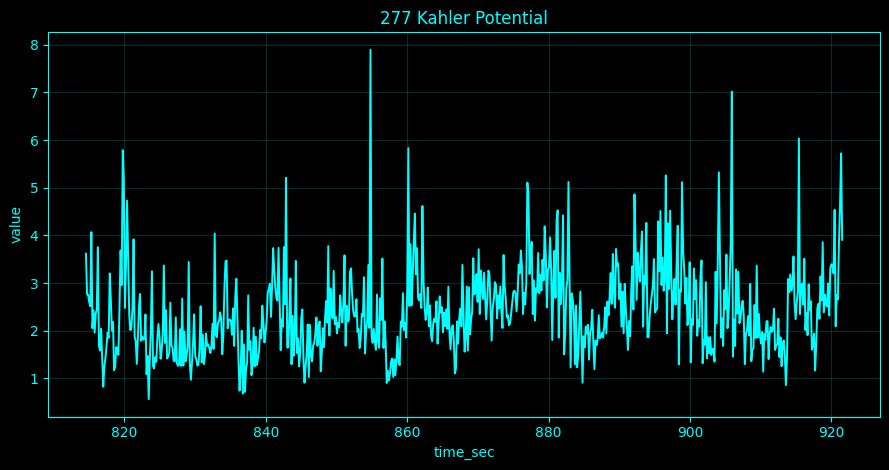

,time_sec,FS_kahler_potential_chart0
0,814.571,3.616172
1,814.724,2.762709
2,814.877,2.758750
3,815.030,2.604989
4,815.183,2.515019
...,...,...
695,920.902,2.656972
696,921.055,3.826686
697,921.208,4.610772
698,921.361,5.722026


In [287]:
z0=np.maximum(np.abs(CP[:,0]),1e-12);Kpot=-2*np.log(z0);scsave('277_kahler_potential',pd.DataFrame({'time_sec':CPT,'FS_kahler_potential_chart0':Kpot}))


### Kähler metric stability


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> The Fubini-Study Kähler metric in affine coordinates w has components g_{a bar b}=((1+||w||²)δ_ab-conj(w_a)w_b)/(1+||w||²)². Stability is assessed from its eigenvalue condition number and relative change between neighboring sampled states in a fixed chart.<br><br>$$g_{a\bar b}=\frac{(1+\|w\|^2)\delta_{ab}-\bar w_a w_b}{(1+\|w\|^2)^2}.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  metric_condition_number  relative_metric_change
  814.571                37.194899                0.000000
  814.724                15.842705                1.386801
  814.877                15.780109                0.047945
  815.030                13.531074                0.219958
  815.183                12.366847                0.119383
  815.336                58.444978                0.794816
  815.489                 7.813838                6.540506
  815.642                11.305889                0.331415
  815.795                 7.111410                0.656317
  815.948                10.569228                0.374165
  816.101                11.571201                0.106462
  816.254                42.621929                0.747110


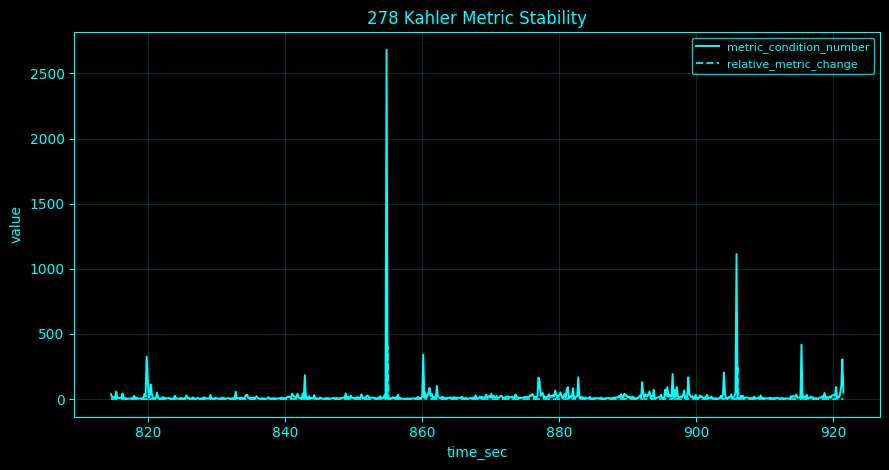

,time_sec,metric_condition_number,relative_metric_change
0,814.571,37.194899,0.000000
1,814.724,15.842705,1.386801
2,814.877,15.780109,0.047945
3,815.030,13.531074,0.219958
4,815.183,12.366847,0.119383
...,...,...,...
695,920.902,14.253071,0.196218
696,921.055,45.910137,0.693914
697,921.208,100.561802,0.551649
698,921.361,305.523241,0.682648


In [288]:
rows=[];last=None
for t0,z in zip(CPT,CP):
 if abs(z[0])<1e-8:continue
 w=z[1:]/z[0];r2=float(np.vdot(w,w).real);g=((1+r2)*np.eye(len(w))-np.outer(np.conj(w),w))/(1+r2)**2;ev=np.linalg.eigvalsh((g+g.conj().T)/2);chg=np.linalg.norm(g-last,'fro')/(np.linalg.norm(last,'fro')+EPS) if last is not None else 0.;rows.append((t0,ev.max()/max(ev.min(),EPS),chg));last=g
scsave('278_kahler_metric_stability',pd.DataFrame(rows,columns=['time_sec','metric_condition_number','relative_metric_change']))


### Kähler curvature diagnostics


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> With the normalization d_FS=arccos|z*w|, complex projective space has constant holomorphic sectional curvature 4. For complex dimension m=n-1, the real scalar curvature is 4m(m+1). These are exact geometric constants, not data-varying EEG curvatures.<br><br>$$H_{hol}=4,\qquad \mathrm{Scal}=4m(m+1).$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


 complex_dimension  holomorphic_sectional_curvature  real_scalar_curvature
                 7                              4.0                    224


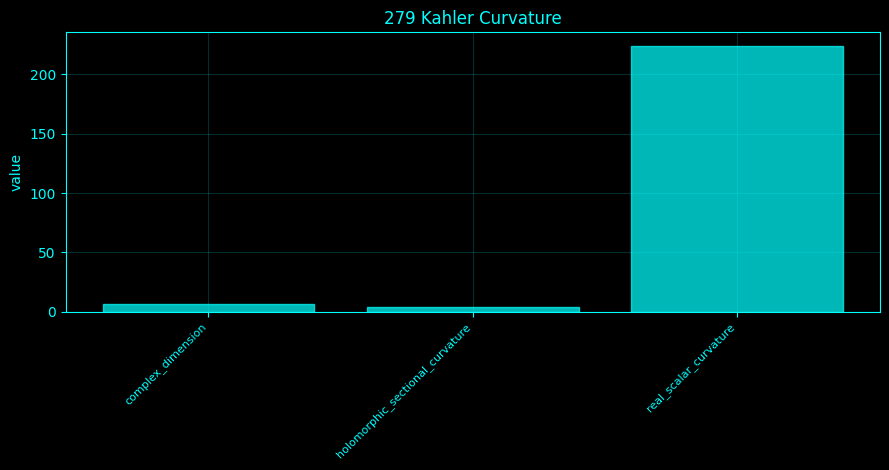

,complex_dimension,holomorphic_sectional_curvature,real_scalar_curvature
0,7,4.0,224


In [289]:
mcp=CP.shape[1]-1;scsave('279_kahler_curvature',pd.DataFrame({'complex_dimension':[mcp],'holomorphic_sectional_curvature':[4.0],'real_scalar_curvature':[4*mcp*(mcp+1)]}))


### Complex phase-amplitude manifold geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> The analytic multichannel state decomposes into total amplitude r=||z|| and projective direction [z]. The product of log-amplitude changes and Fubini-Study angular changes provides a transparent phase-amplitude manifold description.<br><br>$$z=r\hat z,\qquad r=\|z\|,\quad [\hat z]\in\mathbb{CP}^{n-1}.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


 time_sec  log_amplitude_step  projective_step  combined_product_metric_proxy
  814.571            0.000000         0.000000                       0.000000
  814.724            0.673776         0.426483                       0.797410
  814.877            0.144047         0.089133                       0.169393
  815.030            0.077848         0.244998                       0.257069
  815.183            0.121478         0.127755                       0.176290
  815.336            0.099060         0.431046                       0.442282
  815.489            0.173360         0.609637                       0.633807
  815.642            0.047268         0.276499                       0.280510
  815.795            0.041128         0.437791                       0.439719
  815.948            0.071532         0.424612                       0.430595
  816.101            0.033361         0.118755                       0.123352
  816.254            0.203968         0.638804                  

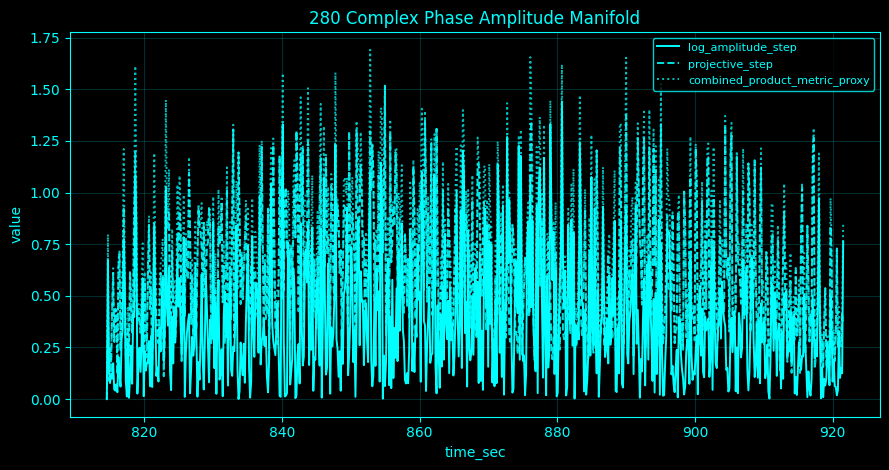

,time_sec,log_amplitude_step,projective_step,combined_product_metric_proxy
0,814.571,0.000000,0.000000,0.000000
1,814.724,0.673776,0.426483,0.797410
2,814.877,0.144047,0.089133,0.169393
3,815.030,0.077848,0.244998,0.257069
4,815.183,0.121478,0.127755,0.176290
...,...,...,...,...
695,920.902,0.329164,0.301302,0.446242
696,921.055,0.102523,0.277633,0.295958
697,921.208,0.150101,0.255899,0.296672
698,921.361,0.125092,0.417881,0.436203


In [290]:
Zraw=AN[ci,:8];amp=np.linalg.norm(Zraw,axis=1);damp=np.r_[0,np.abs(np.diff(np.log(amp+EPS)))];dfs=np.r_[0,[fsdist(CP[i],CP[i+1]) for i in range(len(CP)-1)]];scsave('280_complex_phase_amplitude_manifold',pd.DataFrame({'time_sec':CPT,'log_amplitude_step':damp,'projective_step':dfs,'combined_product_metric_proxy':np.sqrt(damp*damp+dfs*dfs)}))


### Unitary-invariant distance metrics


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> Hermitian-SPD AIRM is invariant under unitary congruence C -> U C U*. A deterministic unitary transform is applied to verify that pairwise distances are unchanged to numerical precision.<br><br>$$d(UCU^*,UDU^*)=d(C,D),\qquad U^*U=I.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 max_airm_invariance_error  mean_airm_invariance_error
              2.442491e-14                8.004437e-15


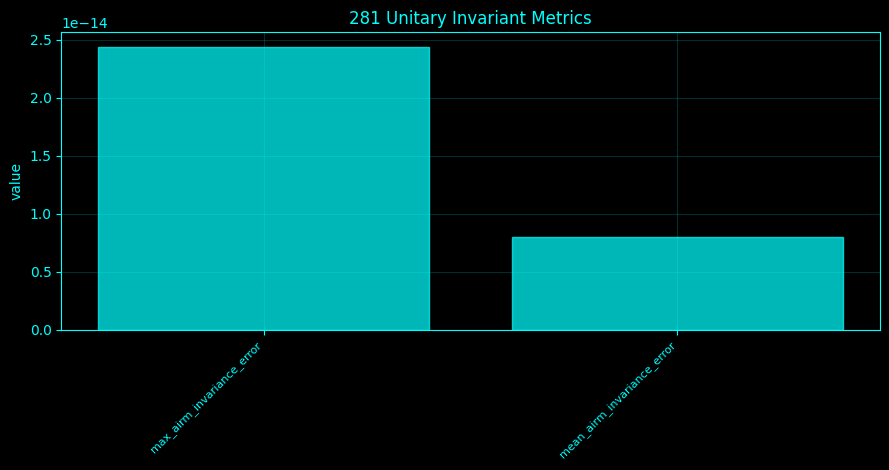

,max_airm_invariance_error,mean_airm_invariance_error
0,2.442491e-14,8.004437e-15


In [291]:
rng=np.random.default_rng(281);Q0,_=np.linalg.qr(rng.normal(size=(HC.shape[1],HC.shape[1]))+1j*rng.normal(size=(HC.shape[1],HC.shape[1])));errs=[]
for i in range(len(HC)-1):errs.append(abs(hairm(HC[i],HC[i+1])-hairm(Q0@HC[i]@Q0.conj().T,Q0@HC[i+1]@Q0.conj().T)))
scsave('281_unitary_invariant_metrics',pd.DataFrame({'max_airm_invariance_error':[max(errs) if errs else 0.],'mean_airm_invariance_error':[np.mean(errs) if errs else 0.]}))


### Complex geodesic interpolation


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> A Fubini-Study geodesic is obtained by first phase-aligning the endpoint so z*w is real nonnegative, then using spherical interpolation in the two-dimensional complex span. Distance from the start grows linearly with interpolation parameter.<br><br>$$\gamma(t)=\frac{\sin((1-t)\theta)}{\sin\theta}z+\frac{\sin(t\theta)}{\sin\theta}w^\prime.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


  t  distance_from_start  expected
0.0             0.000001  0.000000
0.1             0.017233  0.017233
0.2             0.034467  0.034467
0.3             0.051700  0.051700
0.4             0.068934  0.068934
0.5             0.086167  0.086167
0.6             0.103401  0.103401
0.7             0.120634  0.120634
0.8             0.137868  0.137868
0.9             0.155101  0.155101
1.0             0.172335  0.172335


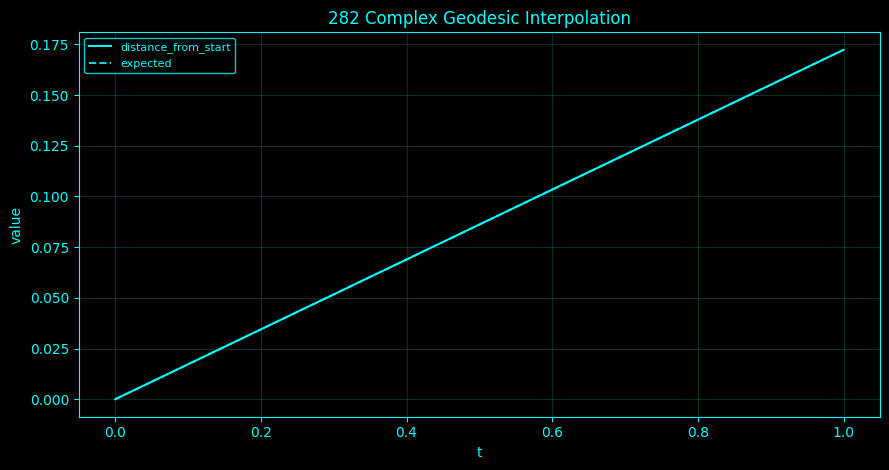

,t,distance_from_start,expected
0,0.0,0.000001,0.000000
1,0.1,0.017233,0.017233
2,0.2,0.034467,0.034467
3,0.3,0.051700,0.051700
4,0.4,0.068934,0.068934
5,0.5,0.086167,0.086167
6,0.6,0.103401,0.103401
7,0.7,0.120634,0.120634
8,0.8,0.137868,0.137868
9,0.9,0.155101,0.155101


In [292]:
z,w=CP[0],CP[-1];w=w*np.exp(-1j*np.angle(np.vdot(z,w)));theta=np.arccos(np.clip(np.real(np.vdot(z,w)),-1,1));rows=[]
for u in np.linspace(0,1,11):
 g=z if theta<1e-10 else np.sin((1-u)*theta)/np.sin(theta)*z+np.sin(u*theta)/np.sin(theta)*w;g/=np.linalg.norm(g)+EPS;rows.append((u,fsdist(z,g),u*theta))
scsave('282_complex_geodesic_interpolation',pd.DataFrame(rows,columns=['t','distance_from_start','expected']))


### Complex tangent-space PCA


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> After phase-aligning each projective state to a fixed reference, its first-order tangent component is the Hermitian-orthogonal projection v=(I-zz*)delta. PCA on concatenated real and imaginary tangent coordinates summarizes local complex-projective variation.<br><br>$$v=(I-zz^*)\delta z,\qquad z^*v=0.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 component  variance_fraction
         1           0.424183
         2           0.262844
         3           0.058228
         4           0.049436
         5           0.040011
         6           0.038293
         7           0.027105
         8           0.024049
         9           0.020354
        10           0.017908


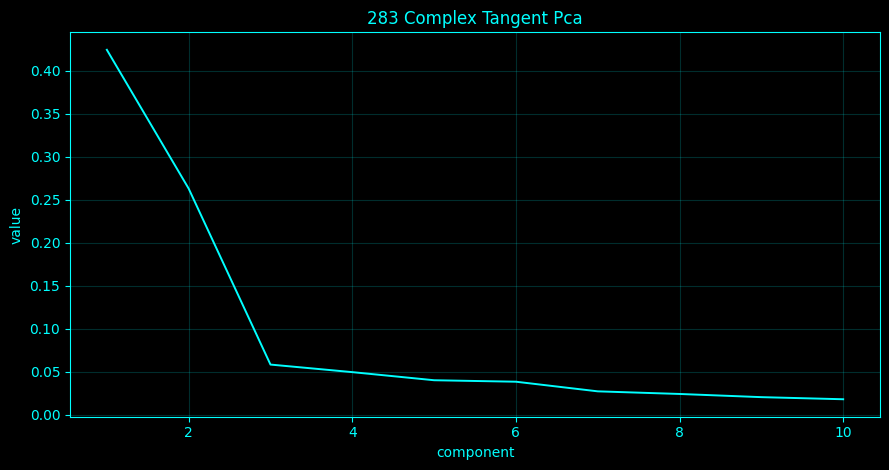

,component,variance_fraction
0,1,0.424183
1,2,0.262844
2,3,0.058228
3,4,0.049436
4,5,0.040011
5,6,0.038293
6,7,0.027105
7,8,0.024049
8,9,0.020354
9,10,0.017908


In [293]:
ref=CP[0];TV=[]
for z in CP:
 za=z*np.exp(-1j*np.angle(np.vdot(ref,z)));v=za-ref*np.vdot(ref,za);TV.append(np.r_[v.real,v.imag])
TV=np.asarray(TV);_,s,_=np.linalg.svd(TV-TV.mean(0),full_matrices=False);ev=s*s/max(len(TV)-1,1);scsave('283_complex_tangent_pca',pd.DataFrame({'component':np.arange(1,min(10,len(ev))+1),'variance_fraction':ev[:10]/(ev.sum()+EPS)}))


### Complex subspace geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> Complex covariance eigenspaces are compared by principal angles from singular values of X*Y. Besides the geodesic norm ||theta||, the chordal distance sqrt(sum sin²theta) provides a basis-invariant complex-subspace descriptor.<br><br>$$\cos\theta_j=\sigma_j(X^*Y),\qquad d_{ch}=\sqrt{\sum_j\sin^2\theta_j}.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  grassmann_distance  chordal_distance
  818.071            1.155696          0.918053
  820.571            0.414172          0.404840
  823.071            1.134118          0.911111
  825.571            0.576322          0.554377
  828.071            0.316399          0.312687
  830.571            0.504538          0.486693
  833.071            0.667979          0.629419
  835.571            1.472638          1.025579
  838.071            0.890186          0.811277
  840.571            0.797363          0.728882
  843.071            1.082538          0.892719
  845.571            1.563055          1.036196


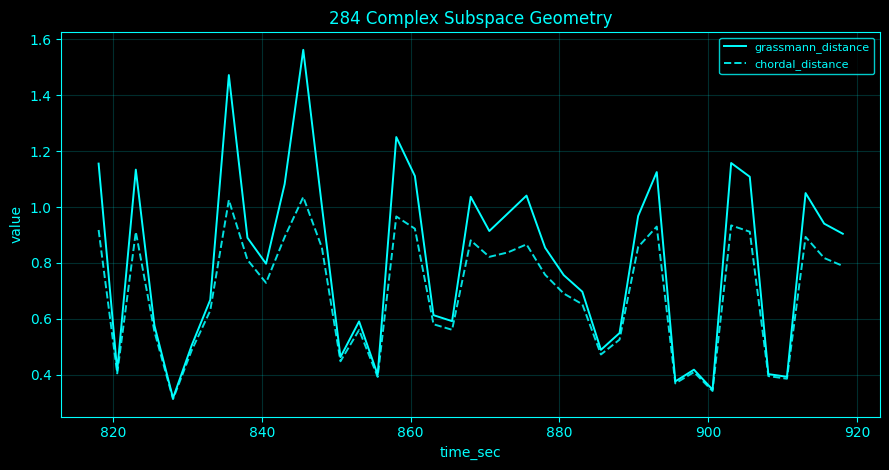

,time_sec,grassmann_distance,chordal_distance
0,818.071,1.155696,0.918053
1,820.571,0.414172,0.404840
2,823.071,1.134118,0.911111
3,825.571,0.576322,0.554377
4,828.071,0.316399,0.312687
5,830.571,0.504538,0.486693
6,833.071,0.667979,0.629419
7,835.571,1.472638,1.025579
8,838.071,0.890186,0.811277
9,840.571,0.797363,0.728882


In [294]:
k=min(3,HC.shape[1]);HUS=[]
for C in HC:
 w,V=np.linalg.eigh(C);HUS.append(V[:,np.argsort(w)[-k:]])
def cangles(X,Y):return np.arccos(np.clip(np.linalg.svd(X.conj().T@Y,compute_uv=False),-1,1))
rows=[]
for i in range(len(HUS)-1):
 a=cangles(HUS[i],HUS[i+1]);rows.append((HT[i+1],np.linalg.norm(a),np.linalg.norm(np.sin(a))))
scsave('284_complex_subspace_geometry',pd.DataFrame(rows,columns=['time_sec','grassmann_distance','chordal_distance']))


### Complex Grassmannian analysis


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> The complete principal-angle vector between successive complex covariance eigenspaces is retained. This distinguishes rotation concentrated in one direction from distributed complex-subspace rotation.<br><br>$$0\le\theta_1\le\cdots\le\theta_k\le\pi/2.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  theta_1  theta_2  theta_3
  818.071 0.021214 0.087265 1.152201
  820.571 0.017951 0.139766 0.389463
  823.071 0.021293 0.115221 1.128048
  825.571 0.012972 0.247387 0.520364
  828.071 0.021132 0.131651 0.286931
  830.571 0.009671 0.146716 0.482638
  833.071 0.010925 0.227918 0.627797
  835.571 0.025784 0.259455 1.449372
  838.071 0.029662 0.383023 0.803022
  840.571 0.017727 0.237673 0.760911
  843.071 0.016739 0.167103 1.069432
  845.571 0.019917 0.276185 1.538332


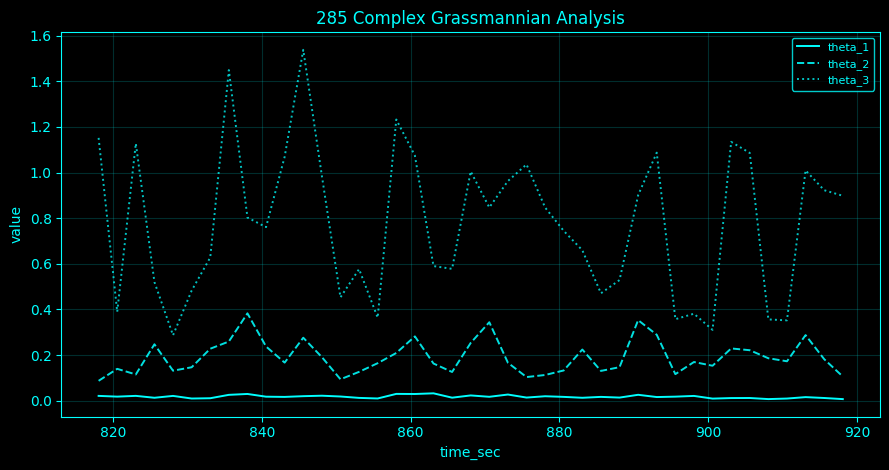

,time_sec,theta_1,theta_2,theta_3
0,818.071,0.021214,0.087265,1.152201
1,820.571,0.017951,0.139766,0.389463
2,823.071,0.021293,0.115221,1.128048
3,825.571,0.012972,0.247387,0.520364
4,828.071,0.021132,0.131651,0.286931
5,830.571,0.009671,0.146716,0.482638
6,833.071,0.010925,0.227918,0.627797
7,835.571,0.025784,0.259455,1.449372
8,838.071,0.029662,0.383023,0.803022
9,840.571,0.017727,0.237673,0.760911


In [295]:
rows=[]
for i in range(len(HUS)-1):rows.append((HT[i+1],*cangles(HUS[i],HUS[i+1])))
scsave('285_complex_grassmannian_analysis',pd.DataFrame(rows,columns=['time_sec']+[f'theta_{j+1}' for j in range(k)]))


# Geometry catalogue continuation — entries 286–319


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> This block uses three explicitly model-based geometries. Lorentzian quantities come from a chosen Minkowski embedding and do not represent physical spacetime or causal influence. Finsler quantities use a valid positive Randers norm. Control geometry is based on a fitted linear state model and finite-horizon controllability Gramians.<br><br>$$g_L=\operatorname{diag}(-1,1,1,1),\qquad F(v)=\sqrt{v^TAv}+b^Tv,\qquad W_T=\int_0^T e^{A\tau}BB^Te^{A^T\tau}\,d\tau.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


Lorentz/Finsler/control foundation: ultra points 650 dual Randers norm 0.35000000000000003 Gramian rank 4


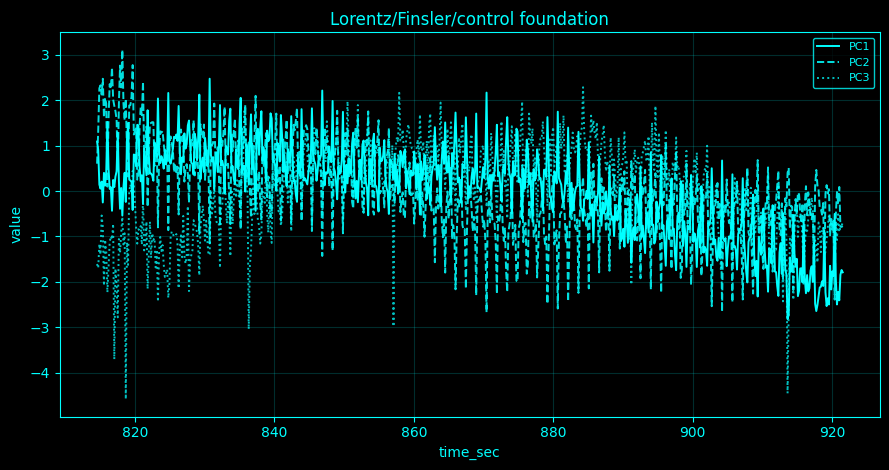

True

In [296]:
from scipy.linalg import expm
from scipy.sparse.csgraph import shortest_path as directed_shortest_path
LC_CFG={'full':dict(points=2200,te_ch=24,te_n=18000,quad=180,horizon=.8),'balanced':dict(points=1600,te_ch=20,te_n=13000,quad=130,horizon=.7),'fast':dict(points=1100,te_ch=16,te_n=8500,quad=90,horizon=.6),'ultra':dict(points=650,te_ch=10,te_n=5000,quad=55,horizon=.5)}[FAST_OPTION]
LC_OUT=os.path.join(base_dir,'results','geometry_catalogue_lorentz_finsler_control');os.makedirs(LC_OUT,exist_ok=True)
def lcdir(s):d=os.path.join(LC_OUT,s);os.makedirs(d,exist_ok=True);return d
def lcsave(s,df):df.to_csv(os.path.join(lcdir(s),f'{s}_{FAST_OPTION}.csv'),index=False);print(df.head(12).to_string(index=False));catalogue_autoplot_df(s,df);return df
# Common continuous PCA state sampled regularly.
m=min(len(EEG_STD),LC_CFG['points']);li=np.unique(np.linspace(0,len(EEG_STD)-1,m).round().astype(int));LX=EEG_STD[li];LT=start_time+li/sampling_rate
_,_,LVT=np.linalg.svd(LX-LX.mean(0),full_matrices=False);S3=(LX-LX.mean(0))@LVT[:3].T;S3/=np.std(S3,axis=0,keepdims=True)+EPS
# Minkowski embedding: time-like coordinate scale tied to median spatial speed.
dsp=np.linalg.norm(np.diff(S3,axis=0),axis=1);dtt=np.diff(LT);cL=1.10*np.median(dsp/(dtt+EPS));TAU=cL*(LT-LT[0]);LZ=np.c_[TAU,S3];ETA=np.diag([-1.,1.,1.,1.])
def lint(a,b):d=np.asarray(b)-np.asarray(a);return float(d@ETA@d)
def boost_x(beta):
 beta=float(beta);ga=1/np.sqrt(1-beta*beta);B=np.eye(4);B[0,0]=B[1,1]=ga;B[0,1]=B[1,0]=-ga*beta;return B
# Constant-coefficient Randers metric on 3-D PCA state.
CF=np.cov(S3,rowvar=False);AF=np.linalg.inv(CF+.08*np.trace(CF)/3*np.eye(3));AF/=np.linalg.det(AF)**(1/3)
AIF=np.linalg.inv(AF);u=np.array([1.,-.4,.25]);u/=np.linalg.norm(u);bF=.35*u/np.sqrt(u@AIF@u)
def minkF(v):v=np.asarray(v,float);return float(np.sqrt(max(v@AF@v,0)))
def randF(v):v=np.asarray(v,float);return minkF(v)+float(bF@v)
# Four-dimensional continuous state for linear control model.
dC=4;XC=(LX-LX.mean(0))@LVT[:dC].T;XC/=np.std(XC,axis=0,keepdims=True)+EPS;dXC=np.gradient(XC,LT,axis=0)
Araw=np.linalg.solve(XC.T@XC+1e-4*np.eye(dC),XC.T@dXC).T;mr=np.max(np.real(np.linalg.eigvals(Araw)));AC=Araw-(mr+.15)*np.eye(dC) if mr>-.15 else Araw.copy()
# Two horizontal control directions from two reproducible scalp loadings, orthonormalized.
b0=np.c_[LVT[:dC,CHANNEL_INDEX['C3']],LVT[:dC,CHANNEL_INDEX['C4']]];BC=np.linalg.qr(b0)[0][:,:2]
def gramian(A,B,T=None,nq=None):
 T=LC_CFG['horizon'] if T is None else float(T);nq=LC_CFG['quad'] if nq is None else int(nq);ts=np.linspace(0,T,nq);W=np.zeros((A.shape[0],A.shape[0]))
 for k,t0 in enumerate(ts):
  E=expm(A*t0);M=E@B@B.T@E.T;w=.5 if k in (0,len(ts)-1) else 1.;W+=w*M
 return .5*(W+W.T)*(T/(len(ts)-1))
def min_energy(A,B,x0,x1,T=None):
 T=LC_CFG['horizon'] if T is None else float(T);W=gramian(A,B,T);Phi=expm(A*T);d=np.asarray(x1)-Phi@np.asarray(x0);Wi=np.linalg.pinv(W,rcond=1e-10);proj=W@Wi@d;res=np.linalg.norm(d-proj);tol=1e-7*(1+np.linalg.norm(d))
 return (float(d@Wi@d) if res<=tol else np.nan),res,W
WC=gramian(AC,BC)
print('Lorentz/Finsler/control foundation:',FAST_OPTION,'points',len(S3),'dual Randers norm',np.sqrt(bF@AIF@bF),'Gramian rank',np.linalg.matrix_rank(WC,tol=1e-9))

# Visible foundation diagnostic
catalogue_autoplot_df('lorentz_finsler_control_foundation',pd.DataFrame({'time_sec':LT,'PC1':S3[:,0],'PC2':S3[:,1],'PC3':S3[:,2]}),title='Lorentz/Finsler/control foundation')


### Lorentzian geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> The low-dimensional embedding is equipped with the flat Minkowski bilinear form of signature (-,+,+,+). It is an indefinite mathematical model only; it does not imply physical spacetime or physiological relativistic causality.<br><br>$$g(u,v)=-u_0v_0+u_1v_1+u_2v_2+u_3v_3.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  signed_interval_sq
  814.736           -0.228422
  814.901            0.936025
  815.065           -0.723999
  815.230            0.007094
  815.395           -0.407118
  815.560            2.038687
  815.724            0.496587
  815.889           -0.612881
  816.054            4.524941
  816.219            2.840704
  816.384            0.259880
  816.548           -0.760993


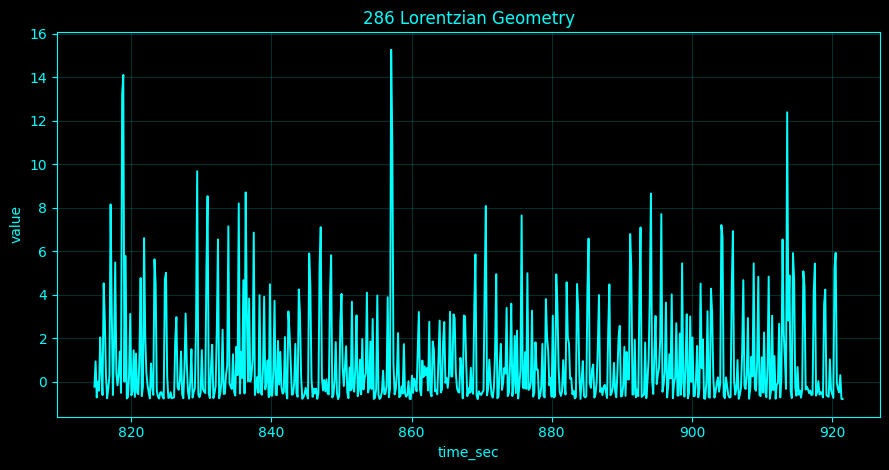

,time_sec,signed_interval_sq
0,814.736,-0.228422
1,814.901,0.936025
2,815.065,-0.723999
3,815.230,0.007094
4,815.395,-0.407118
...,...,...
644,920.855,-0.342763
645,921.020,-0.484188
646,921.184,0.304487
647,921.349,-0.787163


In [297]:
d=np.diff(LZ,axis=0);s2=np.einsum('ij,jk,ik->i',d,ETA,d);lcsave('286_lorentzian_geometry',pd.DataFrame({'time_sec':LT[1:],'signed_interval_sq':s2}))


### Causal cone geometry of EEG state transitions


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> Relative to a reference state, a later point lies inside the modeled future timelike cone when delta tau>0 and its Minkowski interval is negative. This is a cone relation in the chosen embedding, not a causal-neural inference.<br><br>$$\Delta\tau>0,\qquad g(\Delta X,\Delta X)<0.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol τ (tau) commonly denotes a time delay, scale, or characteristic time. Here it should be read according to the definition immediately preceding the formula.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  signed_interval_from_reference  future_timelike_cone
  814.571                   -37192.908880                     0
  814.736                   -36849.145798                     0
  814.901                   -36509.101088                     0
  815.065                   -36169.075593                     0
  815.230                   -35833.489736                     0
  815.395                   -35494.238384                     0
  815.560                   -35152.940886                     0
  815.724                   -34825.347213                     0
  815.889                   -34491.201479                     0
  816.054                   -34151.690516                     0
  816.219                   -33828.799675                     0
  816.384                   -33502.422750                     0


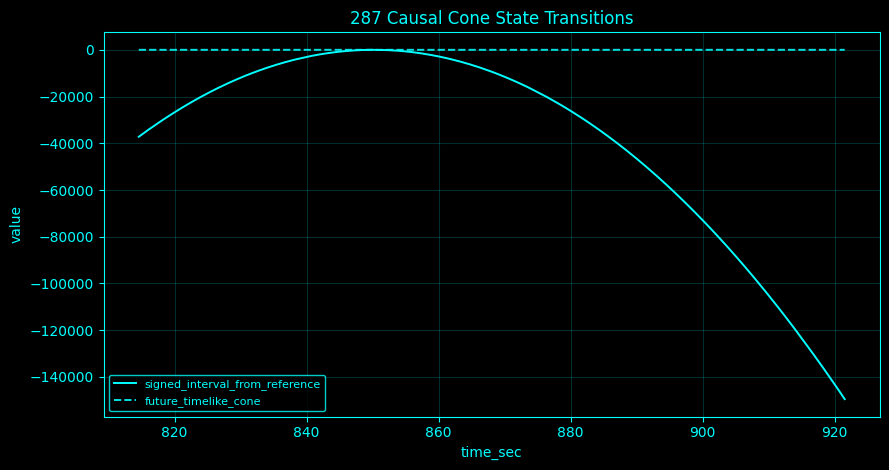

,time_sec,signed_interval_from_reference,future_timelike_cone
0,814.571,-37192.908880,0
1,814.736,-36849.145798,0
2,814.901,-36509.101088,0
3,815.065,-36169.075593,0
4,815.230,-35833.489736,0
...,...,...,...
645,920.855,-146734.065276,1
646,921.020,-147418.695076,1
647,921.184,-148101.887097,1
648,921.349,-148791.363043,1


In [298]:
r0=len(LZ)//3;ds=np.array([lint(LZ[r0],z) for z in LZ]);future=(TAU>TAU[r0])&(ds<0);lcsave('287_causal_cone_state_transitions',pd.DataFrame({'time_sec':LT,'signed_interval_from_reference':ds,'future_timelike_cone':future.astype(int)}))


### Minkowski interval distributions


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> The signed Minkowski squared interval is retained because Lorentzian separation is not a positive-definite distance. Quantiles and sign fractions summarize its empirical distribution for consecutive transitions.<br><br>$$s^2=-(\Delta\tau)^2+\|\Delta x\|^2.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol τ (tau) commonly denotes a time delay, scale, or characteristic time. Here it should be read according to the definition immediately preceding the formula.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 quantile  signed_interval_sq
     0.00           -0.798825
     0.10           -0.713447
     0.25           -0.571576
     0.50           -0.137073
     0.75            1.646182
     0.90            4.302099
     1.00           15.267333


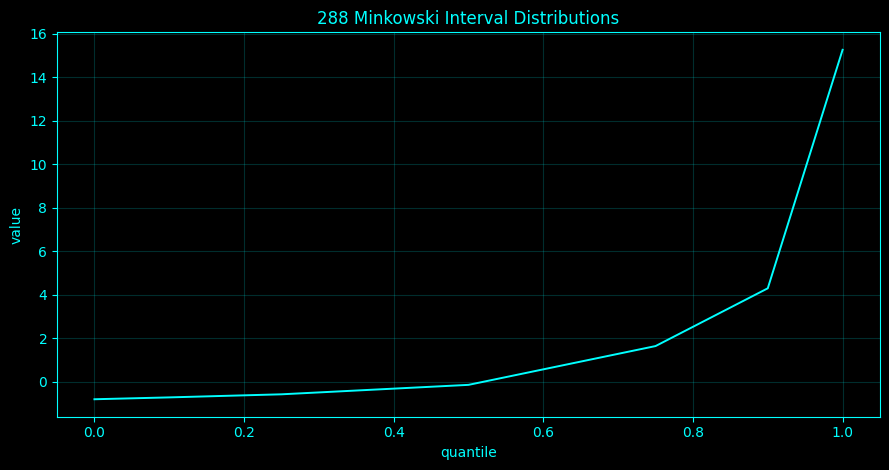

,quantile,signed_interval_sq
0,0.00,-0.798825
1,0.10,-0.713447
2,0.25,-0.571576
3,0.50,-0.137073
4,0.75,1.646182
5,0.90,4.302099
6,1.00,15.267333


In [299]:
d=np.diff(LZ,axis=0);s2=np.einsum('ij,jk,ik->i',d,ETA,d);qv=np.quantile(s2,[0,.1,.25,.5,.75,.9,1]);lcsave('288_minkowski_interval_distributions',pd.DataFrame({'quantile':[0,.1,.25,.5,.75,.9,1],'signed_interval_sq':qv}))


### Timelike/spacelike/null transition classification


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> With signature (-,+,+,+), negative interval is timelike, positive is spacelike, and values numerically close to zero are null. A scale-relative tolerance avoids classifying floating-point noise as a physical category.<br><br>$$s^2<0:\text{timelike},\quad s^2>0:\text{spacelike},\quad s^2=0:\text{null}.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Statistical significance should be read relative to the stated null model and testing procedure; it is strongest when accompanied by an effect size, uncertainty estimate, and correction for the number of comparisons when many tests are run.</p></div>


    class  count  fraction
spacelike    304  0.468413
 timelike    345  0.531587


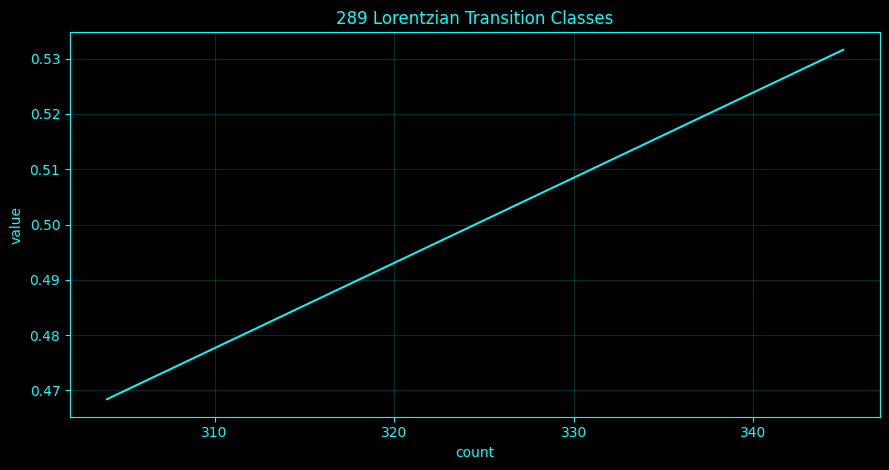

,class,count,fraction
0,spacelike,304,0.468413
1,timelike,345,0.531587


In [300]:
tol=1e-10*max(np.max(np.abs(s2)),1.);lab=np.where(s2<-tol,'timelike',np.where(s2>tol,'spacelike','null'));u,c=np.unique(lab,return_counts=True);lcsave('289_lorentzian_transition_classes',pd.DataFrame({'class':u,'count':c,'fraction':c/len(lab)}))


### Lorentzian distance matrix


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> A Lorentzian distance matrix in the ordinary metric sense does not exist for arbitrary pairs. The notebook therefore stores the signed squared interval matrix and a separate timelike proper-separation matrix, leaving spacelike entries undefined there.<br><br>$$S_{ij}=g(X_j-X_i,X_j-X_i),\qquad d_{proper}=\sqrt{-S_{ij}}\ \text{only if }S_{ij}<0.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


/tmp/ipykernel_142206/2057821722.py:28: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.set_facecolor(BG); ax.grid(grid,alpha=.18,color=ACCENT); ax.tick_params(colors=ACCENT)


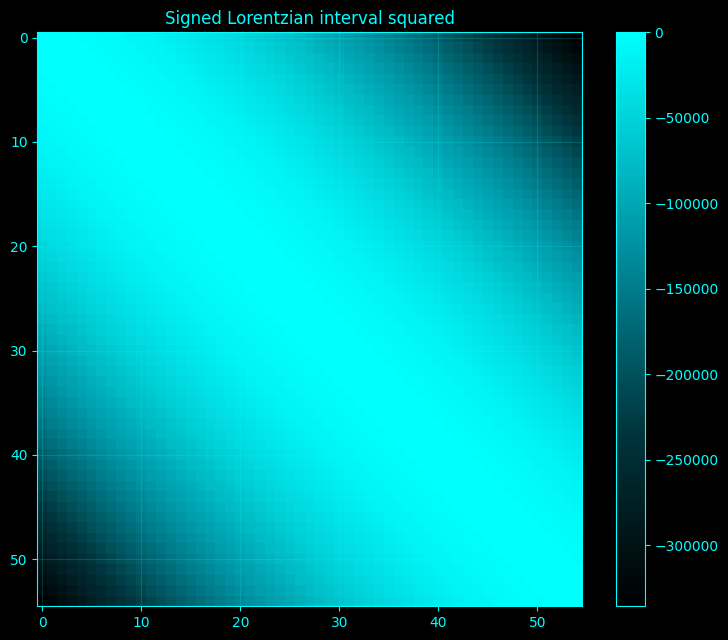

In [301]:
m=min(55,len(LZ));jj=np.unique(np.linspace(0,len(LZ)-1,m).round().astype(int));D=np.array([[lint(LZ[i],LZ[j]) for j in jj] for i in jj]);emit_matrix('290_lorentzian_distance_matrix','Signed Lorentzian interval squared',D,[f'{LT[i]:.2f}' for i in jj]);TP=np.where(D<0,np.sqrt(np.maximum(-D,0)),np.nan);pd.DataFrame(TP).to_csv(os.path.join(lcdir('290_lorentzian_distance_matrix'),f'timelike_proper_{FAST_OPTION}.csv'),index=False)


### Lorentzian geodesic proxy


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> Flat Minkowski geodesics are affine straight lines. The proxy compares an endpoint chord with the observed embedded trajectory; geodesicity of the chord itself is exact in this flat model, while deviation of the EEG path from it is data dependent.<br><br>$$\gamma(u)=(1-u)X_0+uX_1,\qquad \ddot\gamma=0.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


 time_sec  euclidean_deviation_from_flat_geodesic_chord
  814.571                                      0.000000
  814.736                                      0.756805
  814.901                                      1.960961
  815.065                                      2.022675
  815.230                                      2.055288
  815.395                                      2.438021
  815.560                                      1.317400
  815.724                                      1.815834
  815.889                                      1.498503
  816.054                                      0.931577
  816.219                                      1.157225
  816.384                                      2.089916


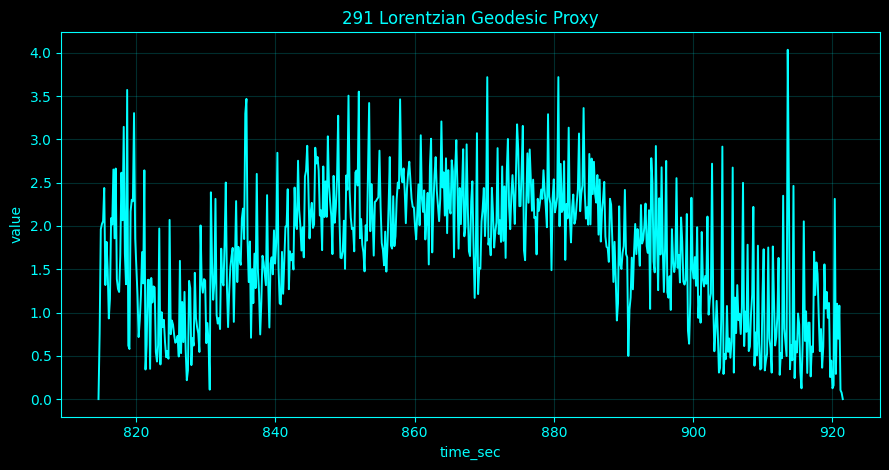

,time_sec,euclidean_deviation_from_flat_geodesic_chord
0,814.571,0.000000
1,814.736,0.756805
2,814.901,1.960961
3,815.065,2.022675
4,815.230,2.055288
...,...,...
645,920.855,0.697713
646,921.020,1.079421
647,921.184,0.104244
648,921.349,0.072968


In [302]:
a,b=0,len(LZ)-1;u=np.linspace(0,1,len(LZ));ch=(1-u)[:,None]*LZ[a]+u[:,None]*LZ[b];dev=np.linalg.norm(LZ-ch,axis=1);lcsave('291_lorentzian_geodesic_proxy',pd.DataFrame({'time_sec':LT,'euclidean_deviation_from_flat_geodesic_chord':dev}))


### Causal-order geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> The Minkowski model induces a partial-order-like relation X_i precedes X_j when j is later in the modeled time coordinate and the separation is nonspacelike. This order is strictly an embedding diagnostic and not a neural causality claim.<br><br>$$X_i\preceq X_j\iff \tau_j\ge\tau_i\ \text{and}\ g(X_j-X_i,X_j-X_i)\le0.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol τ (tau) commonly denotes a time delay, scale, or characteristic time. Here it should be read according to the definition immediately preceding the formula.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 sampled_ordered_pairs  modeled_nonspacelike_future_pairs  fraction
                  2415                               2415       1.0


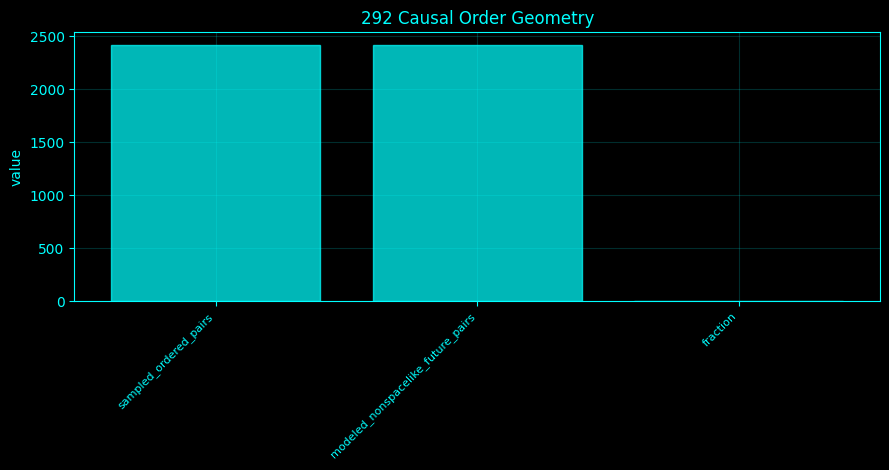

,sampled_ordered_pairs,modeled_nonspacelike_future_pairs,fraction
0,2415,2415,1.0


In [303]:
jj=np.unique(np.linspace(0,len(LZ)-1,min(70,len(LZ))).round().astype(int));pairs=ordered=0
for a in range(len(jj)):
 for b in range(a+1,len(jj)):
  pairs+=1;ordered+=int(lint(LZ[jj[a]],LZ[jj[b]])<=0)
lcsave('292_causal_order_geometry',pd.DataFrame({'sampled_ordered_pairs':[pairs],'modeled_nonspacelike_future_pairs':[ordered],'fraction':[ordered/max(pairs,1)]}))


### Light-cone embedding diagnostics


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> The modeled null cone satisfies ||delta x||=|delta tau|. The cone ratio measures proximity to that boundary and exposes how the chosen time-scale parameter positions observed transitions relative to the light cone.<br><br>$$\rho=\frac{\|\Delta x\|}{|\Delta\tau|},\qquad \rho=1\ \text{on the null cone}.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol τ (tau) commonly denotes a time delay, scale, or characteristic time. Here it should be read according to the definition immediately preceding the formula. The symbol ρ (rho) is often used for a correlation, density, or similarity measure; its role is determined by the equation's definition.</p><p><b>How to interpret this cell.</b> Statistical significance should be read relative to the stated null model and testing procedure; it is strongest when accompanied by an effect size, uncertainty estimate, and correction for the number of comparisons when many tests are run.</p></div>


 time_sec  cone_ratio  abs_ratio_minus_one
  814.736    0.845151             0.154849
  814.901    1.473369             0.473369
  815.065    0.288645             0.711355
  815.230    1.004427             0.004427
  815.395    0.700543             0.299457
  815.560    1.884162             0.884162
  815.724    1.276224             0.276224
  815.889    0.483099             0.516901
  816.054    2.580692             1.580692
  816.219    2.133837             1.133837
  816.384    1.151116             0.151116
  816.548    0.190990             0.809010


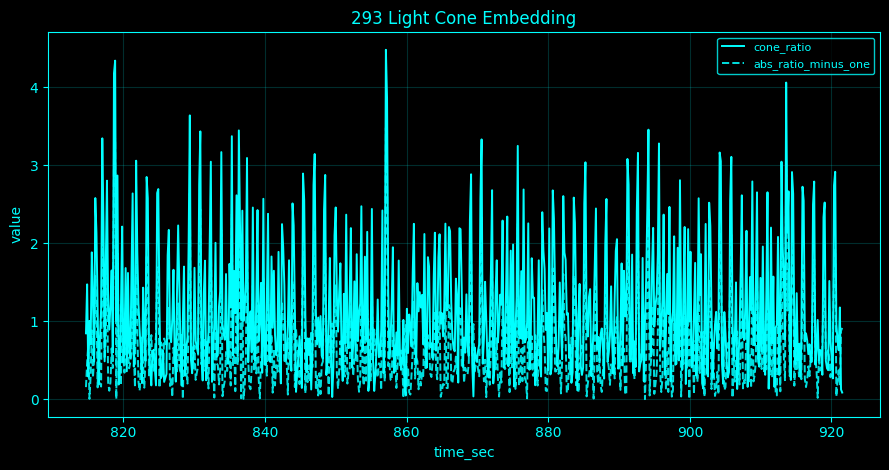

,time_sec,cone_ratio,abs_ratio_minus_one
0,814.736,0.845151,0.154849
1,814.901,1.473369,0.473369
2,815.065,0.288645,0.711355
3,815.230,1.004427,0.004427
4,815.395,0.700543,0.299457
...,...,...,...
644,920.855,0.755817,0.244183
645,921.020,0.627980,0.372020
646,921.184,1.177082,0.177082
647,921.349,0.124039,0.875961


In [304]:
d=np.diff(LZ,axis=0);rho=np.linalg.norm(d[:,1:],axis=1)/(np.abs(d[:,0])+EPS);lcsave('293_light_cone_embedding',pd.DataFrame({'time_sec':LT[1:],'cone_ratio':rho,'abs_ratio_minus_one':np.abs(rho-1)}))


### Pseudo-Riemannian metric fitting


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;line-height:1.5"><b>Theory.</b> A one-parameter diagonal pseudo-Riemannian metric on raw analysis time and PCA space is fitted by setting the temporal scale to the median observed spatial speed. This makes the median consecutive transition null before the deliberate 1.10 timelike bias used in LZ; the fitted parameter is therefore explicit and reproducible.<br><br>$$g_c=\operatorname{diag}(-c^2,1,1,1),\qquad \hat c=\operatorname{median}\frac{\|\Delta x\|}{\Delta t}.$$</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> Statistical significance should be read relative to the stated null model and testing procedure; it is strongest when accompanied by an effect size, uncertainty estimate, and correction for the number of comparisons when many tests are run.</p></div>
